In [1]:
!pip install wandb huggingface_hub -q

## Weights and biases login

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: happykumar_25afi21 (happykumar_25afi21-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Hugging face login

In [3]:
from huggingface_hub import notebook_login
notebook_login()

## importing libraries and setting parameters

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import wandb
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

HF_REPO = "HappyKumar25afi21/exp8-ae-vae"

WANDB_PROJECT = "exp8-ae-vae"
EPOCHS       = 5
BATCH_SIZE   = 128
LATENT_DIMS  = [2, 8, 16, 32]
OPTIMIZERS   = ["adam", "sgd", "rmsprop"]
LOSS_FNS     = ["bce", "mse"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


## Loading Data

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.2MB/s]

train: 48000  val: 12000  test: 10000


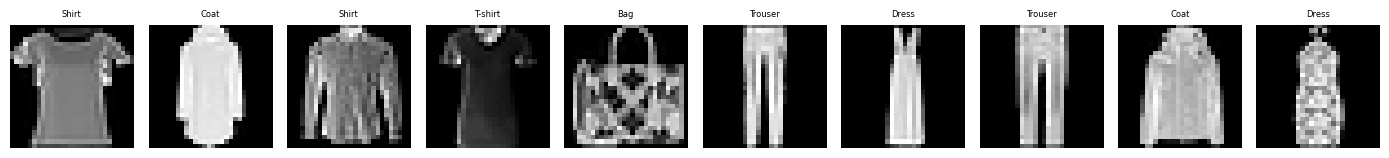

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train

train_set, val_set = random_split(full_train, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_data)}')

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i in range(10):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Autoencoder

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z

## Variational Autoencoder

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

## Loss and optimizer function

In [8]:
def recon_loss(recon, x, loss_type):
    if loss_type == 'bce':
        return nn.BCELoss()(recon, x)
    return nn.MSELoss()(recon, x)

def vae_loss(recon, x, mu, logvar, loss_type):
    r_loss = recon_loss(recon, x, loss_type)
    kl     = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return r_loss + kl, r_loss, kl

def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

## Training and evaluation

In [9]:
def train_ae(model, loader, optimizer, loss_type):
    model.train()
    running = 0
    for x, _ in loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = recon_loss(out, x, loss_type)
        loss.backward()
        optimizer.step()
        running += loss.item()
    return running / len(loader)

def evaluate_ae(model, loader, loss_type):
    model.eval()
    running = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            out, _ = model(x)
            running += recon_loss(out, x, loss_type).item()
    return running / len(loader)

def train_vae(model, loader, optimizer, loss_type):
    model.train()
    t_loss = t_recon = t_kl = 0
    for x, _ in loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out, mu, logvar, _ = model(x)
        loss, rl, kl = vae_loss(out, x, mu, logvar, loss_type)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_recon += rl.item()
        t_kl += kl.item()
    n = len(loader)
    return t_loss/n, t_recon/n, t_kl/n

def evaluate_vae(model, loader, loss_type):
    model.eval()
    t_loss = t_recon = t_kl = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            out, mu, logvar, _ = model(x)
            loss, rl, kl = vae_loss(out, x, mu, logvar, loss_type)
            t_loss += loss.item()
            t_recon += rl.item()
            t_kl += kl.item()
    n = len(loader)
    return t_loss/n, t_recon/n, t_kl/n

In [10]:
def show_reconstructions(model, loader, model_type, title, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(DEVICE)
    with torch.no_grad():
        out = model(x)[0]
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().squeeze(), cmap='gray')
        axes[1, i].imshow(out[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Input', fontsize=8)
    axes[1, 0].set_ylabel('Recon', fontsize=8)
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

def show_latent_2d(model, loader, model_type, title):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            z = model(x)[1] if model_type == 'AE' else model.encode(x)[0]
            zs.append(z.cpu().numpy())
            ys.append(y.numpy())
    zs = np.concatenate(zs)
    ys = np.concatenate(ys)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(zs[:, 0], zs[:, 1], c=ys, cmap='tab10', s=2, alpha=0.5)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_ticks(range(10))
    cb.set_ticklabels(class_names)
    ax.set_title(title)
    ax.set_xlabel('z0')
    ax.set_ylabel('z1')
    plt.tight_layout()
    plt.show()
    return fig

def show_interpolation(model, loader, model_type, title, steps=10):
    model.eval()
    x, _ = next(iter(loader))
    x1 = x[0:1].to(DEVICE)
    x2 = x[1:2].to(DEVICE)
    with torch.no_grad():
        z1 = model(x1)[1] if model_type == 'AE' else model.encode(x1)[0]
        z2 = model(x2)[1] if model_type == 'AE' else model.encode(x2)[0]
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.3, 1.8))
    for i, a in enumerate(np.linspace(0, 1, steps)):
        z = (1 - a) * z1 + a * z2
        with torch.no_grad():
            img = model.decoder(z).view(28, 28) if model_type == 'AE' else model.decode(z).squeeze()
        axes[i].imshow(img.cpu(), cmap='gray')
        axes[i].set_title(f'{a:.1f}', fontsize=6)
        axes[i].axis('off')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

def show_generated(model, title, n=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim).to(DEVICE)
        imgs = model.decode(z)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.3, 1.8))
    for i in range(n):
        axes[i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

In [11]:
results = {}
trained_models = {}

def run_experiment(model_type, latent_dim, opt_name, loss_type):
    name = f'{model_type}_ld{latent_dim}_{opt_name}_{loss_type}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'model': model_type,
        'latent_dim': latent_dim,
        'optimizer': opt_name,
        'loss': loss_type,
        'epochs': EPOCHS
    })

    model     = (Autoencoder(latent_dim) if model_type == 'AE' else VAE(latent_dim)).to(DEVICE)
    optimizer = get_optimizer(model, opt_name)

    for epoch in range(1, EPOCHS + 1):
        if model_type == 'AE':
            tr = train_ae(model, train_loader, optimizer, loss_type)
            vl = evaluate_ae(model, val_loader, loss_type)
            wandb.log({'epoch': epoch, 'train_loss': tr, 'val_loss': vl})
            print(f'  epoch {epoch}/{EPOCHS}  train={tr:.4f}  val={vl:.4f}')
        else:
            tr, tr_r, tr_k = train_vae(model, train_loader, optimizer, loss_type)
            vl, vl_r, vl_k = evaluate_vae(model, val_loader, loss_type)
            wandb.log({
                'epoch': epoch,
                'train_loss': tr, 'train_recon': tr_r, 'train_kl': tr_k,
                'val_loss':   vl, 'val_recon':   vl_r, 'val_kl':   vl_k
            })
            print(f'  epoch {epoch}/{EPOCHS}  train={tr:.4f}  recon={tr_r:.4f}  kl={tr_k:.4f}  val={vl:.4f}')

    if model_type == 'AE':
        test_loss = evaluate_ae(model, test_loader, loss_type)
    else:
        test_loss, _, _ = evaluate_vae(model, test_loader, loss_type)

    print(f'  test_loss={test_loss:.4f}')
    wandb.log({'test_loss': test_loss})

    fig = show_reconstructions(model, test_loader, model_type, name)
    wandb.log({'reconstructions': wandb.Image(fig)})
    plt.close(fig)

    fig = show_interpolation(model, test_loader, model_type, f'interpolation - {name}')
    wandb.log({'interpolation': wandb.Image(fig)})
    plt.close(fig)

    if latent_dim == 2:
        fig = show_latent_2d(model, test_loader, model_type, f'latent 2D - {name}')
        wandb.log({'latent_2d': wandb.Image(fig)})
        plt.close(fig)

    if model_type == 'VAE':
        fig = show_generated(model, f'generated - {name}')
        wandb.log({'generated': wandb.Image(fig)})
        plt.close(fig)

    torch.save(model.state_dict(), f'{name}.pt')
    trained_models[name] = model
    results[name] = test_loss

    wandb.finish()
    return model

##  Quick Test


starting: AE_ld16_adam_bce


  epoch 1/5  train=0.3440  val=0.3063
  epoch 2/5  train=0.2990  val=0.2945
  epoch 3/5  train=0.2913  val=0.2892
  epoch 4/5  train=0.2863  val=0.2856
  epoch 5/5  train=0.2834  val=0.2828
  test_loss=0.2844


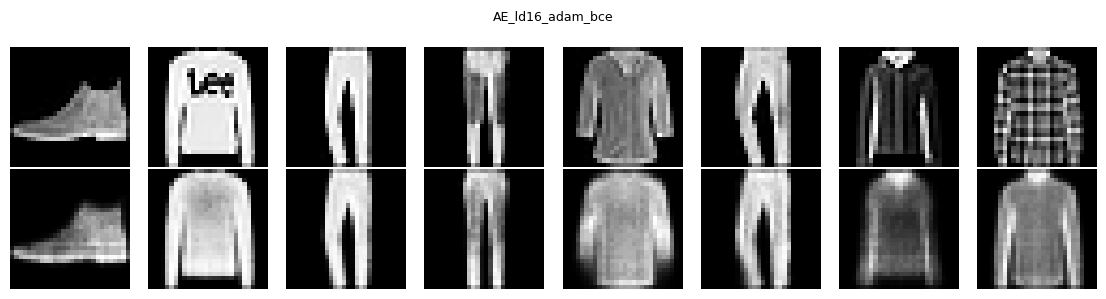

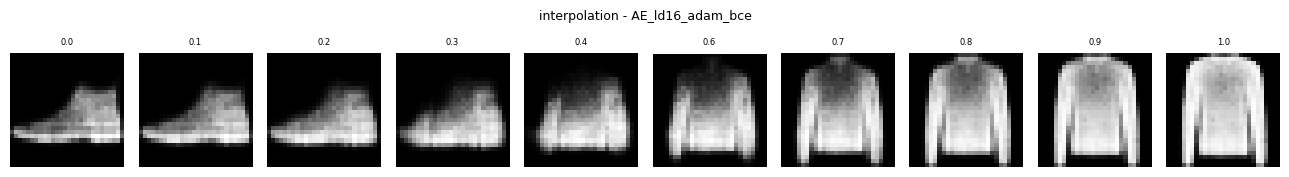

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▃▂▁
epoch,5
test_loss,0.28439
train_loss,0.28339
val_loss,0.28283



starting: VAE_ld16_adam_bce


  epoch 1/5  train=0.4930  recon=0.4838  kl=0.0093  val=0.4850
  epoch 2/5  train=0.4799  recon=0.4464  kl=0.0336  val=0.4792
  epoch 3/5  train=0.4779  recon=0.4338  kl=0.0441  val=0.4780
  epoch 4/5  train=0.4773  recon=0.4302  kl=0.0471  val=0.4768
  epoch 5/5  train=0.4771  recon=0.4291  kl=0.0480  val=0.4778
  test_loss=0.4775


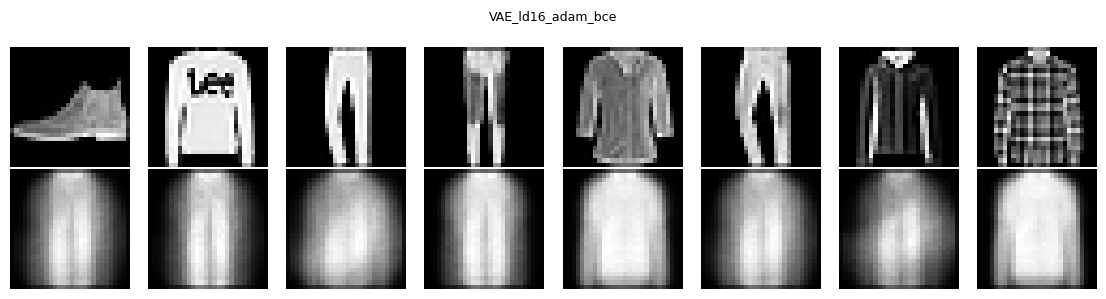

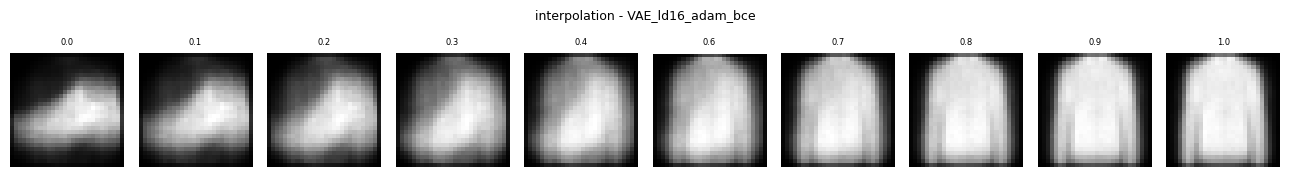

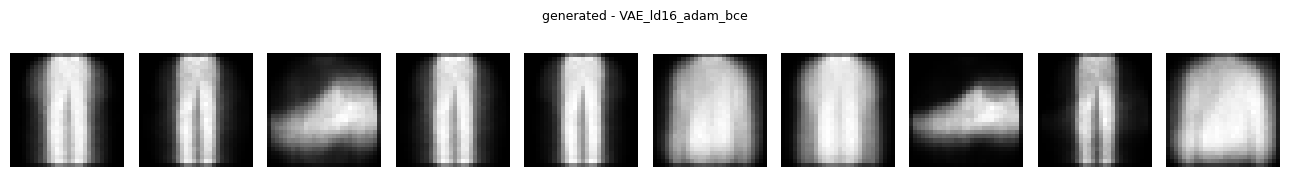

epoch,▁▃▅▆█
test_loss,▁
train_kl,▁▅▇██
train_loss,█▂▁▁▁
train_recon,█▃▂▁▁
val_kl,▁▆██▆
val_loss,█▃▂▁▂
val_recon,█▃▁▁▂
epoch,5
test_loss,0.4775
train_kl,0.04799


VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [12]:
run_experiment('AE',  latent_dim=16, opt_name='adam', loss_type='bce')
run_experiment('VAE', latent_dim=16, opt_name='adam', loss_type='bce')

### Full Grid - all 48 combinations


starting: AE_ld2_adam_bce


  epoch 1/5  train=0.3568  val=0.3322
  epoch 2/5  train=0.3294  val=0.3297
  epoch 3/5  train=0.3263  val=0.3256
  epoch 4/5  train=0.3240  val=0.3245
  epoch 5/5  train=0.3226  val=0.3234
  test_loss=0.3246


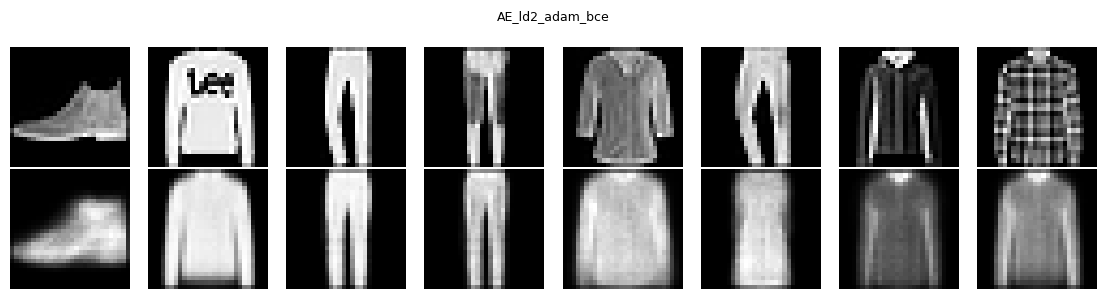

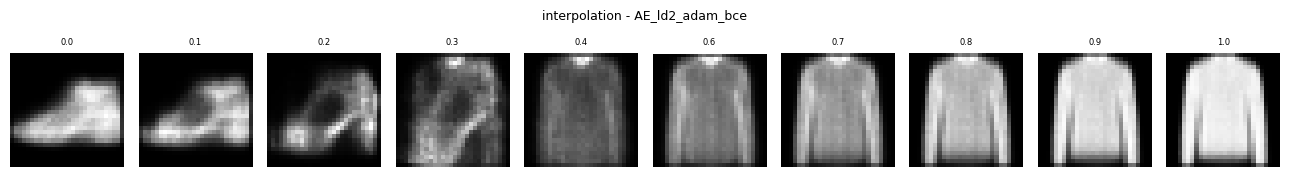

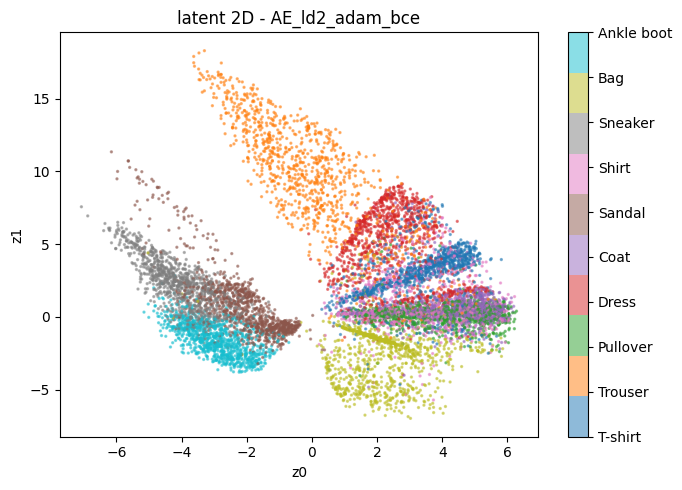

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▂▂▁▁
val_loss,█▆▃▂▁
epoch,5
test_loss,0.32465
train_loss,0.32261
val_loss,0.32337



starting: AE_ld2_adam_mse


  epoch 1/5  train=0.0401  val=0.0326
  epoch 2/5  train=0.0311  val=0.0307
  epoch 3/5  train=0.0294  val=0.0291
  epoch 4/5  train=0.0286  val=0.0285
  epoch 5/5  train=0.0281  val=0.0284
  test_loss=0.0283


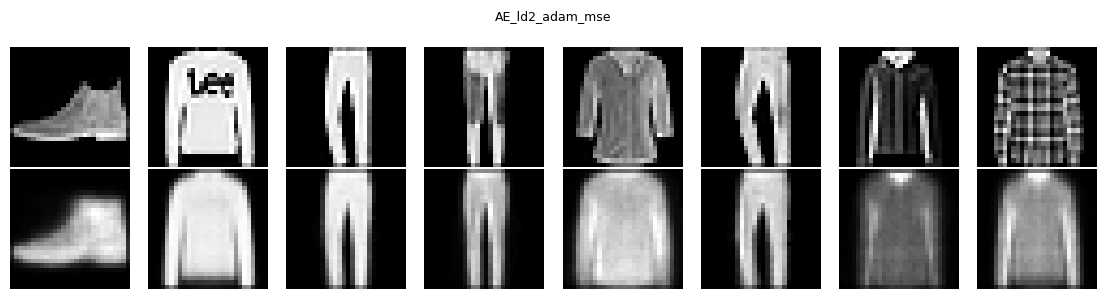

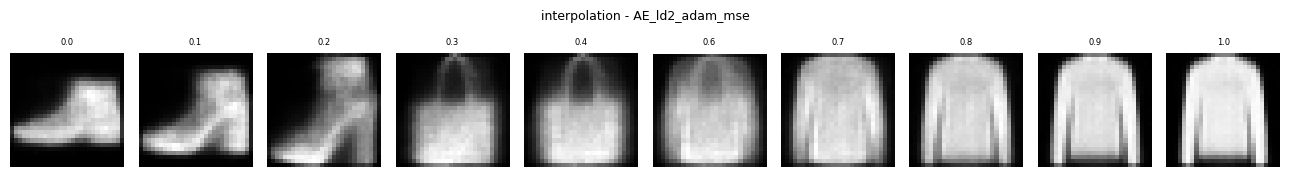

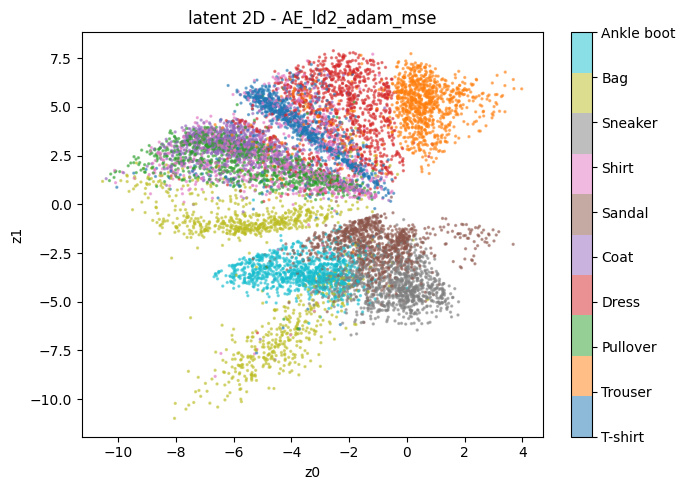

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▅▂▁▁
epoch,5
test_loss,0.02829
train_loss,0.0281
val_loss,0.0284



starting: AE_ld2_sgd_bce


  epoch 1/5  train=0.6921  val=0.6896
  epoch 2/5  train=0.6871  val=0.6845
  epoch 3/5  train=0.6816  val=0.6786
  epoch 4/5  train=0.6751  val=0.6714
  epoch 5/5  train=0.6670  val=0.6622
  test_loss=0.6622


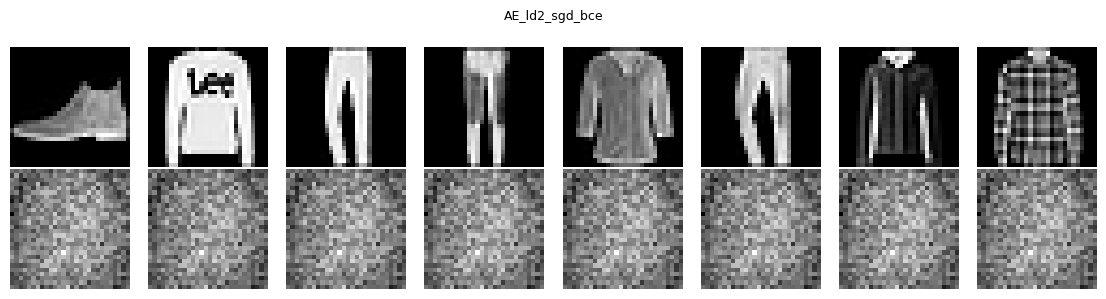

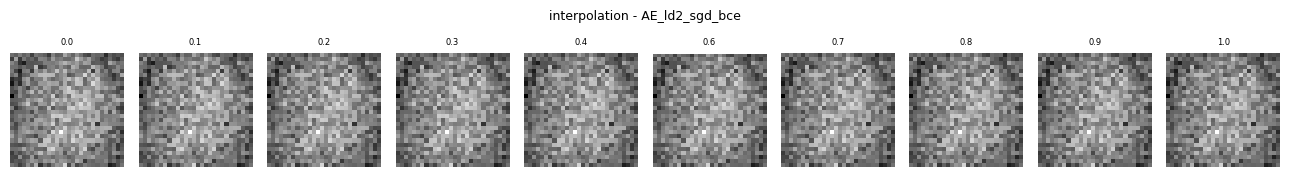

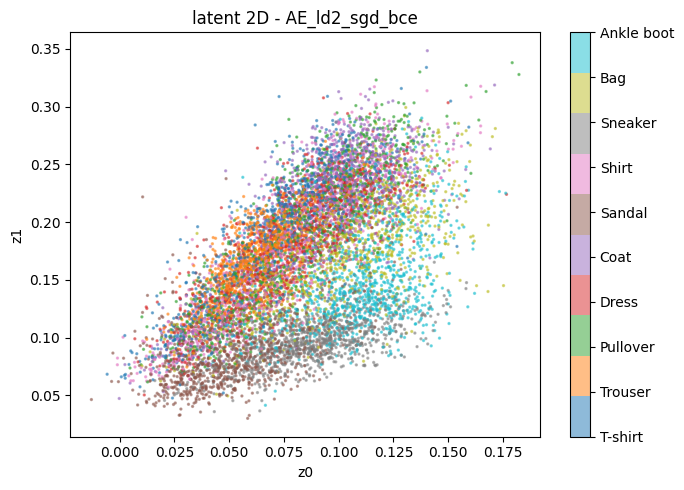

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▇▅▃▁
val_loss,█▇▅▃▁
epoch,5
test_loss,0.66221
train_loss,0.667
val_loss,0.6622



starting: AE_ld2_sgd_mse


  epoch 1/5  train=0.1695  val=0.1689
  epoch 2/5  train=0.1683  val=0.1677
  epoch 3/5  train=0.1671  val=0.1665
  epoch 4/5  train=0.1658  val=0.1652
  epoch 5/5  train=0.1644  val=0.1637
  test_loss=0.1631


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/usr/lib/python3.12/shutil.py", line 759, in rmtree
    _rmtree_safe_fd(stack, onexc)
  File "/usr/lib/python3.12/shutil.py", line 703, in _rmtree_safe_fd
    onexc(func, path, err)
  File "/usr/lib/python3.12/shutil.py", line 750, in onexc
    return onerror(func, path, exc_info)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/shutil.py", line 662, in _rmtree_safe_fd
    os.rmdir(name, dir_fd=dirfd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-b284mft7'


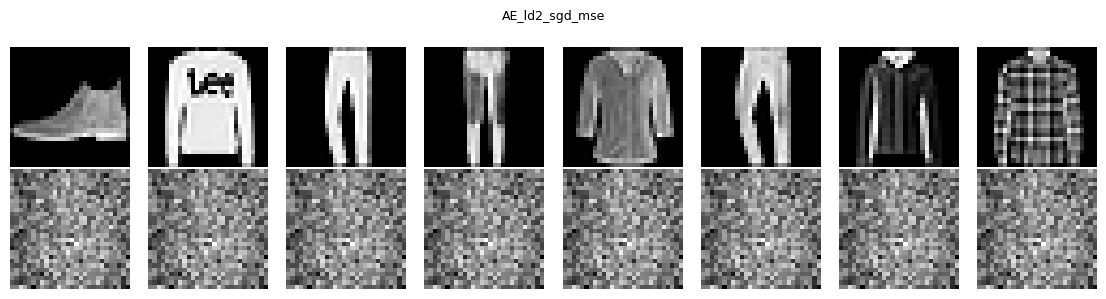

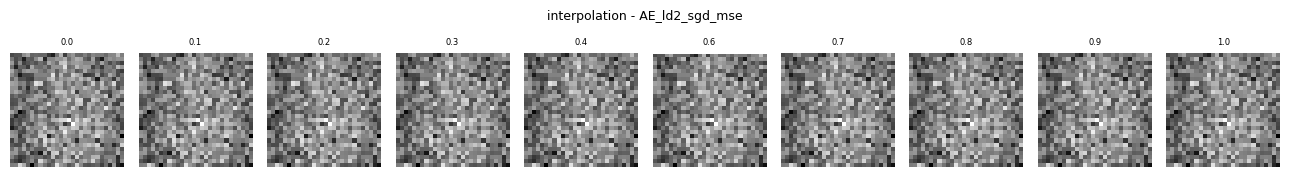

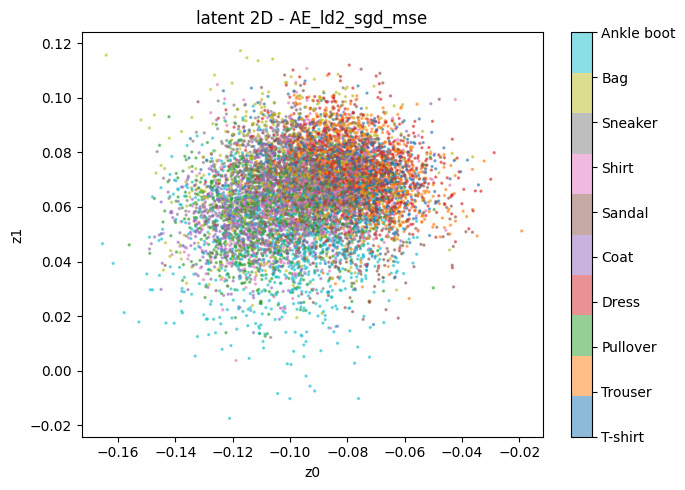

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.16308
train_loss,0.16444
val_loss,0.16371



starting: AE_ld2_rmsprop_bce


  epoch 1/5  train=0.3716  val=0.3395
  epoch 2/5  train=0.3376  val=0.3339
  epoch 3/5  train=0.3321  val=0.3301
  epoch 4/5  train=0.3290  val=0.3293
  epoch 5/5  train=0.3264  val=0.3245
  test_loss=0.3258


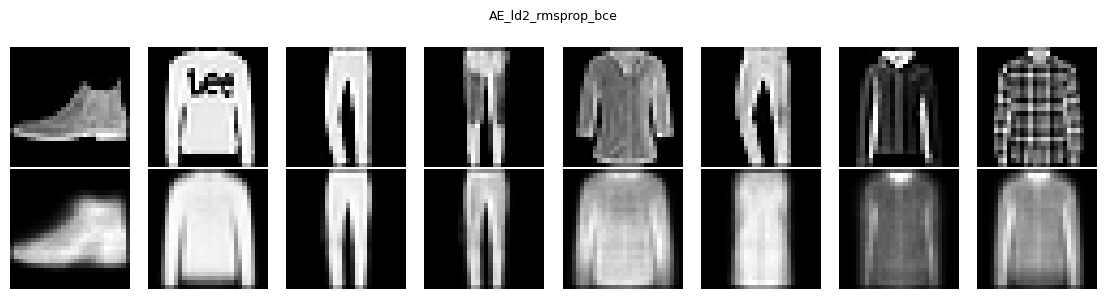

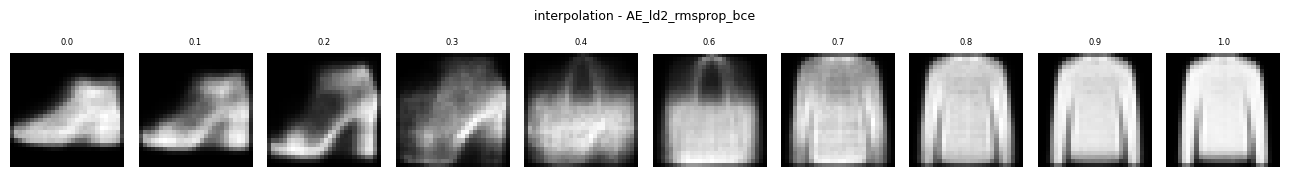

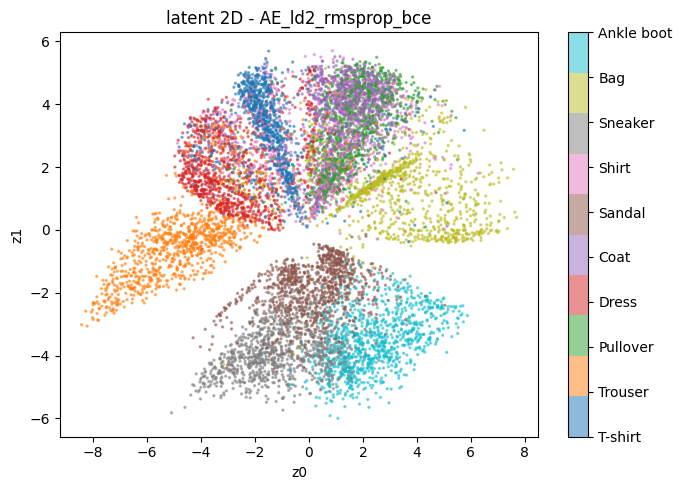

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▅▄▃▁
epoch,5
test_loss,0.32576
train_loss,0.32639
val_loss,0.32452



starting: AE_ld2_rmsprop_mse


  epoch 1/5  train=0.0419  val=0.0336
  epoch 2/5  train=0.0327  val=0.0330
  epoch 3/5  train=0.0308  val=0.0313
  epoch 4/5  train=0.0297  val=0.0290
  epoch 5/5  train=0.0291  val=0.0299
  test_loss=0.0298


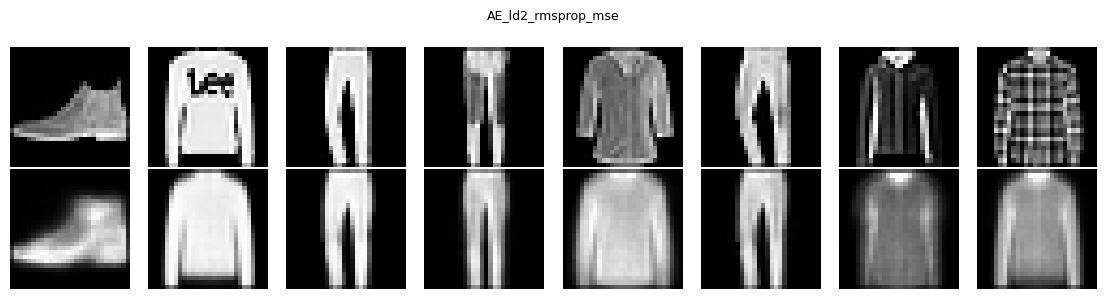

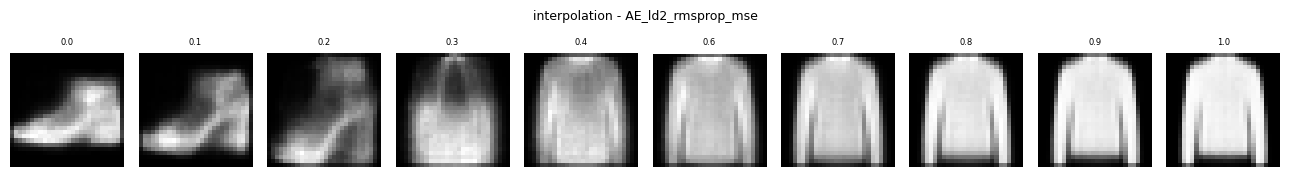

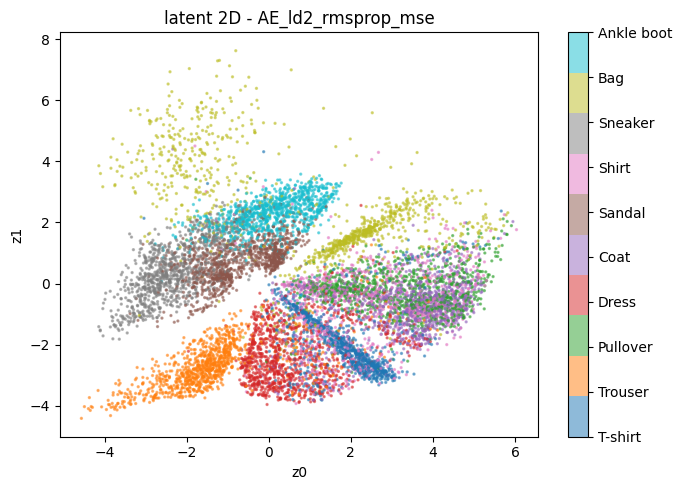

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▇▄▁▂
epoch,5
test_loss,0.02977
train_loss,0.02911
val_loss,0.02987



starting: AE_ld8_adam_bce


  epoch 1/5  train=0.3445  val=0.3054
  epoch 2/5  train=0.2984  val=0.2946
  epoch 3/5  train=0.2912  val=0.2896
  epoch 4/5  train=0.2879  val=0.2874
  epoch 5/5  train=0.2859  val=0.2861
  test_loss=0.2876


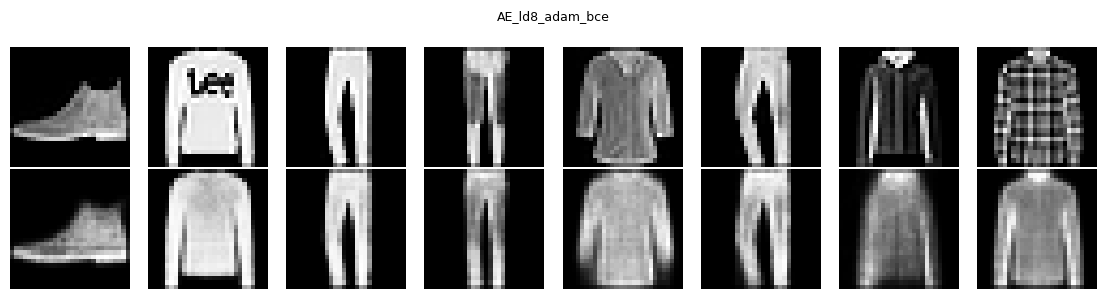

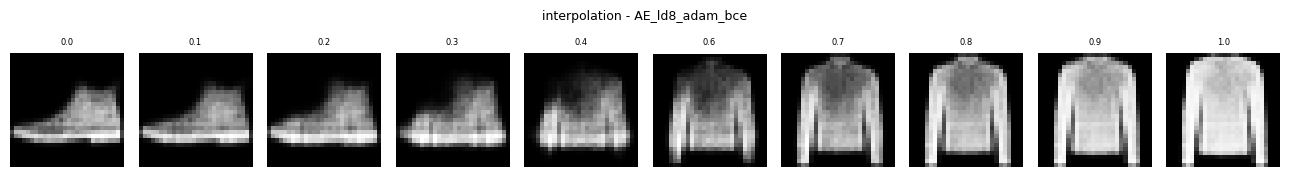

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▂▂▁▁
val_loss,█▄▂▁▁
epoch,5
test_loss,0.28764
train_loss,0.28592
val_loss,0.28608



starting: AE_ld8_adam_mse


  epoch 1/5  train=0.0338  val=0.0209
  epoch 2/5  train=0.0191  val=0.0179
  epoch 3/5  train=0.0167  val=0.0161
  epoch 4/5  train=0.0156  val=0.0154
  epoch 5/5  train=0.0149  val=0.0149
  test_loss=0.0149


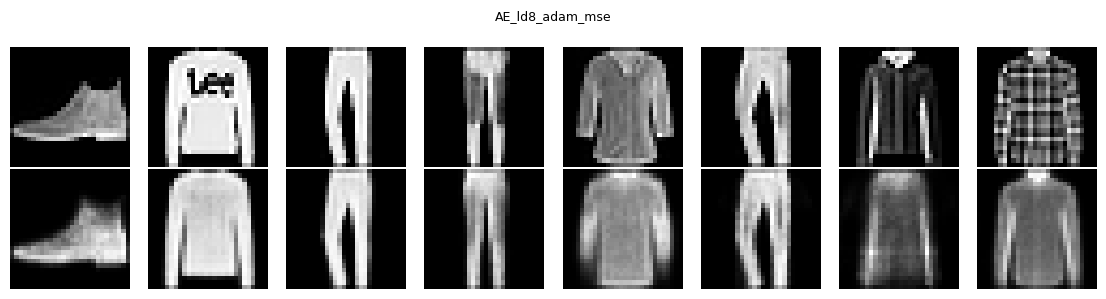

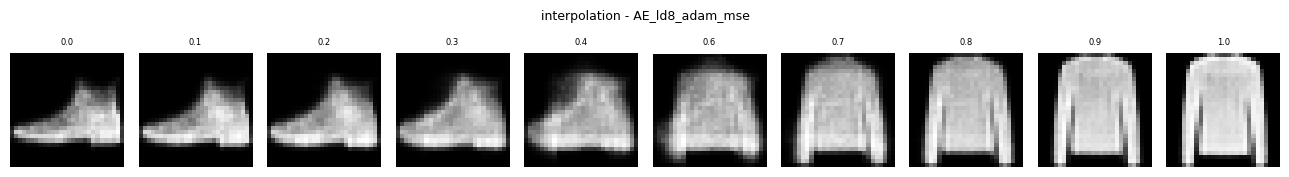

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▂▂▁
epoch,5
test_loss,0.01489
train_loss,0.01492
val_loss,0.01487



starting: AE_ld8_sgd_bce


  epoch 1/5  train=0.6926  val=0.6917
  epoch 2/5  train=0.6907  val=0.6897
  epoch 3/5  train=0.6887  val=0.6877
  epoch 4/5  train=0.6866  val=0.6854
  epoch 5/5  train=0.6842  val=0.6828
  test_loss=0.6828


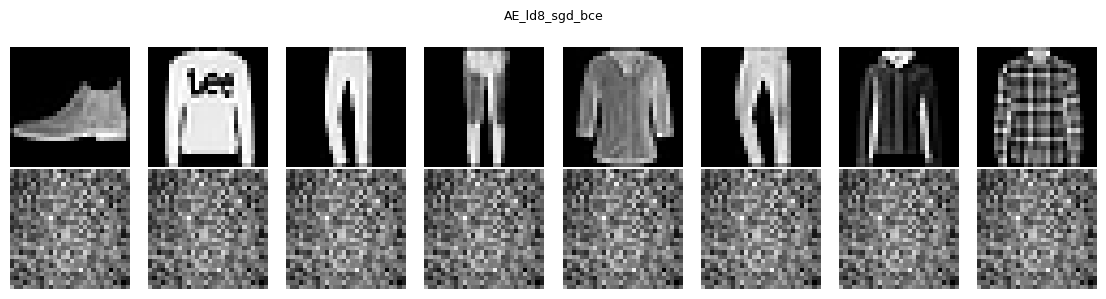

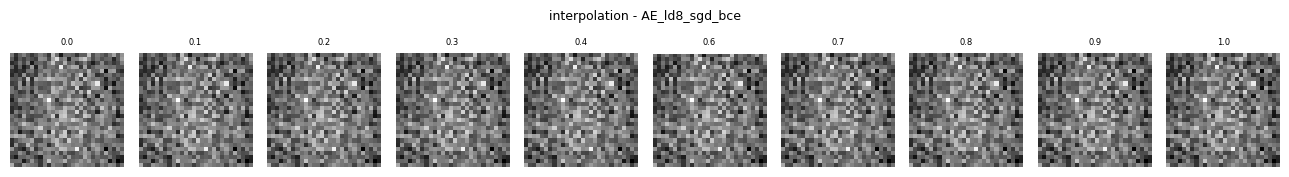

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.68285
train_loss,0.68416
val_loss,0.68284



starting: AE_ld8_sgd_mse


  epoch 1/5  train=0.1704  val=0.1701
  epoch 2/5  train=0.1699  val=0.1696
  epoch 3/5  train=0.1693  val=0.1691
  epoch 4/5  train=0.1688  val=0.1685
  epoch 5/5  train=0.1683  val=0.1680
  test_loss=0.1673


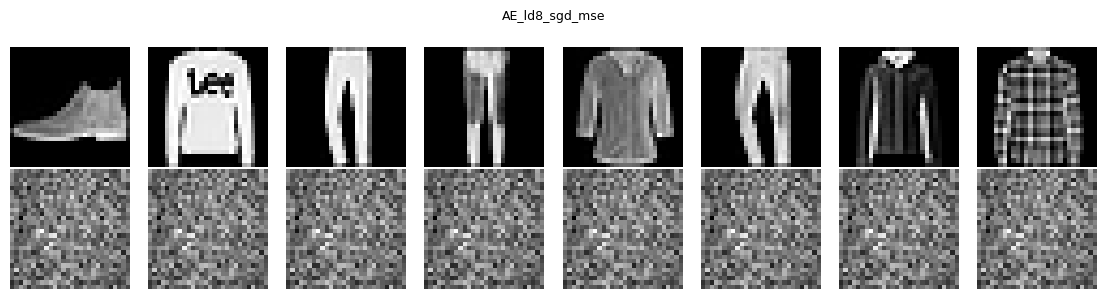

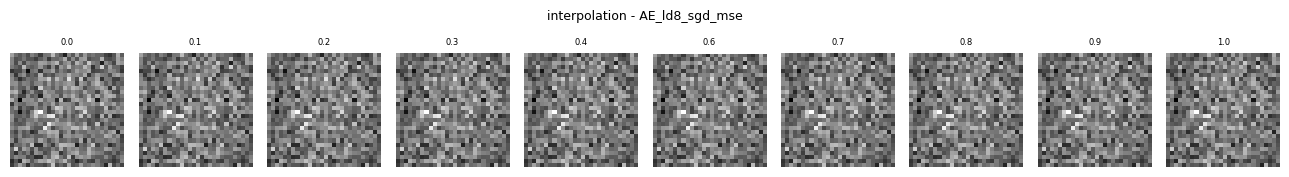

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.16735
train_loss,0.16825
val_loss,0.16797



starting: AE_ld8_rmsprop_bce


  epoch 1/5  train=0.3619  val=0.3263
  epoch 2/5  train=0.3169  val=0.3111
  epoch 3/5  train=0.3066  val=0.3008
  epoch 4/5  train=0.3009  val=0.3018
  epoch 5/5  train=0.2968  val=0.2960
  test_loss=0.2975


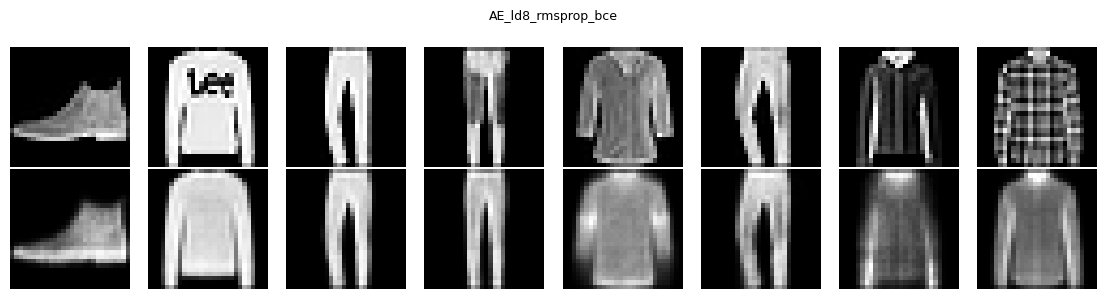

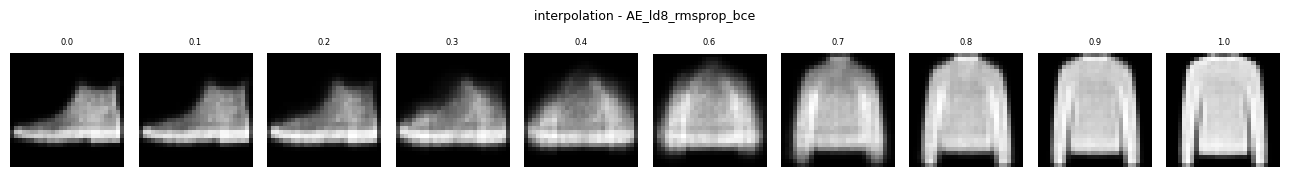

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▂▂▁
epoch,5
test_loss,0.2975
train_loss,0.29677
val_loss,0.29601



starting: AE_ld8_rmsprop_mse


  epoch 1/5  train=0.0370  val=0.0247
  epoch 2/5  train=0.0239  val=0.0225
  epoch 3/5  train=0.0215  val=0.0201
  epoch 4/5  train=0.0199  val=0.0195
  epoch 5/5  train=0.0186  val=0.0181
  test_loss=0.0182


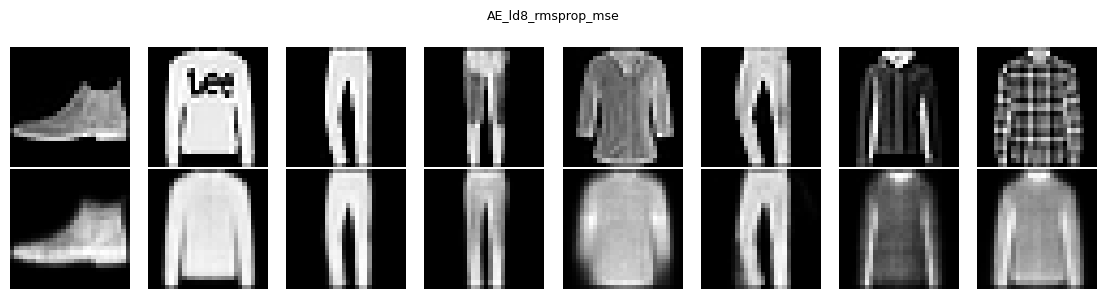

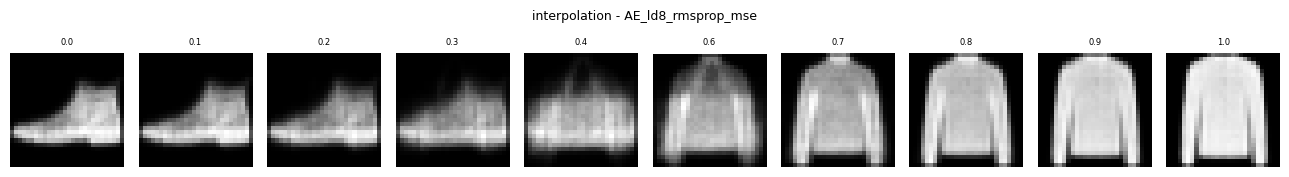

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▆▃▃▁
epoch,5
test_loss,0.01815
train_loss,0.01862
val_loss,0.01812



starting: AE_ld16_adam_bce


  epoch 1/5  train=0.3422  val=0.3083
  epoch 2/5  train=0.2988  val=0.2945
  epoch 3/5  train=0.2907  val=0.2887
  epoch 4/5  train=0.2860  val=0.2847
  epoch 5/5  train=0.2829  val=0.2823
  test_loss=0.2839


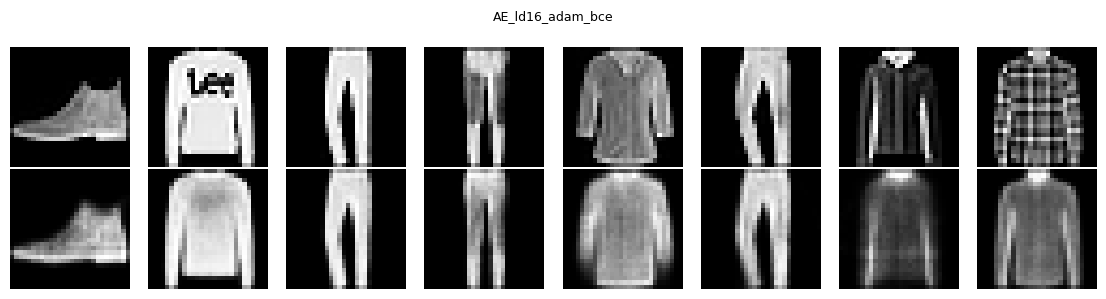

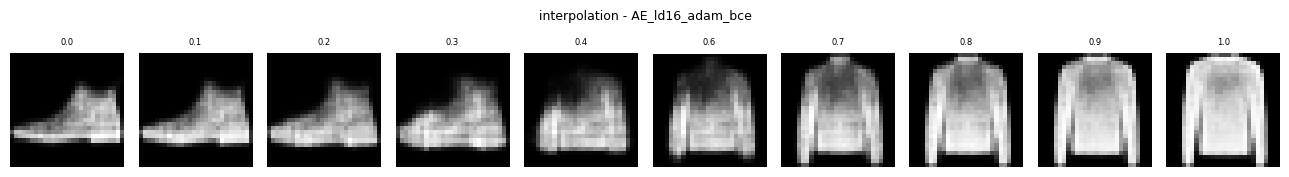

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▃▂▁
epoch,5
test_loss,0.28393
train_loss,0.28286
val_loss,0.28234



starting: AE_ld16_adam_mse


  epoch 1/5  train=0.0340  val=0.0211
  epoch 2/5  train=0.0187  val=0.0172
  epoch 3/5  train=0.0160  val=0.0154
  epoch 4/5  train=0.0145  val=0.0142
  epoch 5/5  train=0.0135  val=0.0133
  test_loss=0.0133


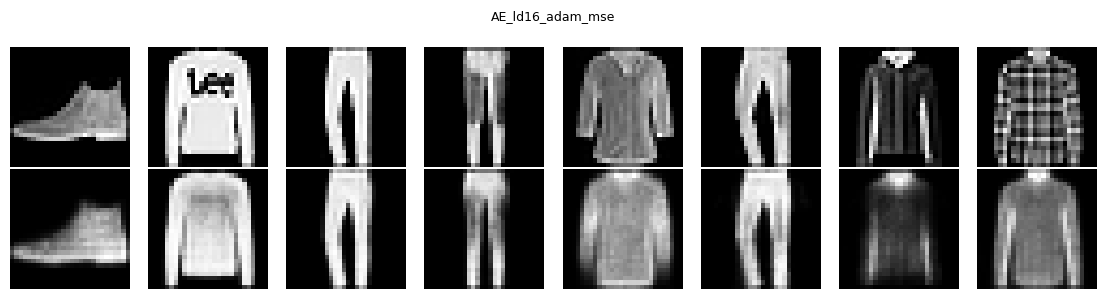

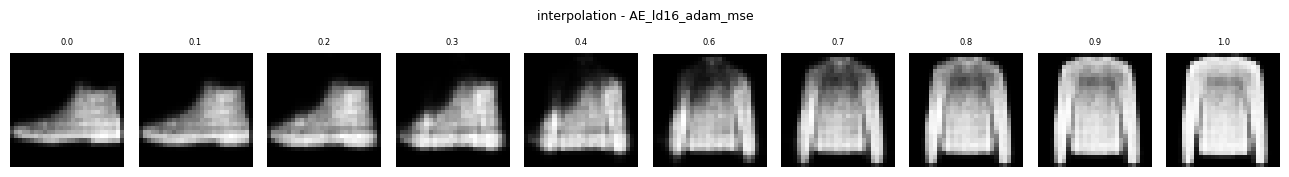

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▃▂▁
epoch,5
test_loss,0.01331
train_loss,0.01349
val_loss,0.01327



starting: AE_ld16_sgd_bce


  epoch 1/5  train=0.6932  val=0.6927
  epoch 2/5  train=0.6922  val=0.6917
  epoch 3/5  train=0.6912  val=0.6907
  epoch 4/5  train=0.6902  val=0.6897
  epoch 5/5  train=0.6892  val=0.6886
  test_loss=0.6886


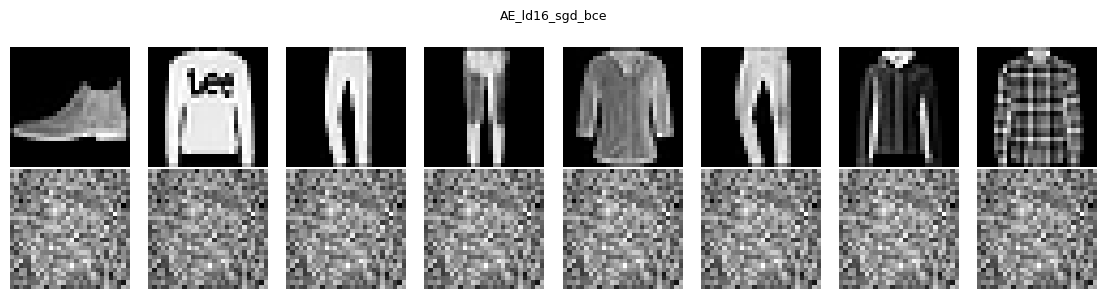

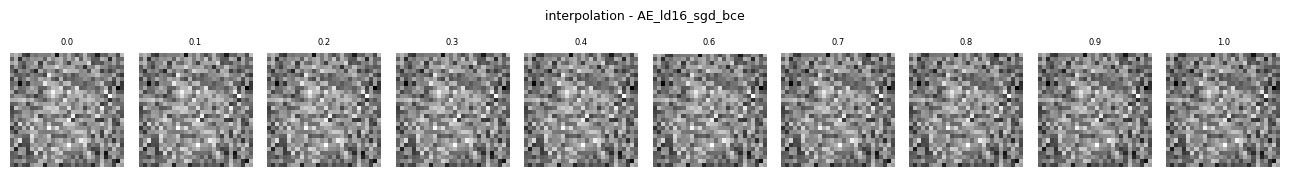

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.68864
train_loss,0.68917
val_loss,0.68863



starting: AE_ld16_sgd_mse


  epoch 1/5  train=0.1703  val=0.1701
  epoch 2/5  train=0.1699  val=0.1698
  epoch 3/5  train=0.1696  val=0.1694
  epoch 4/5  train=0.1693  val=0.1691
  epoch 5/5  train=0.1689  val=0.1688
  test_loss=0.1681


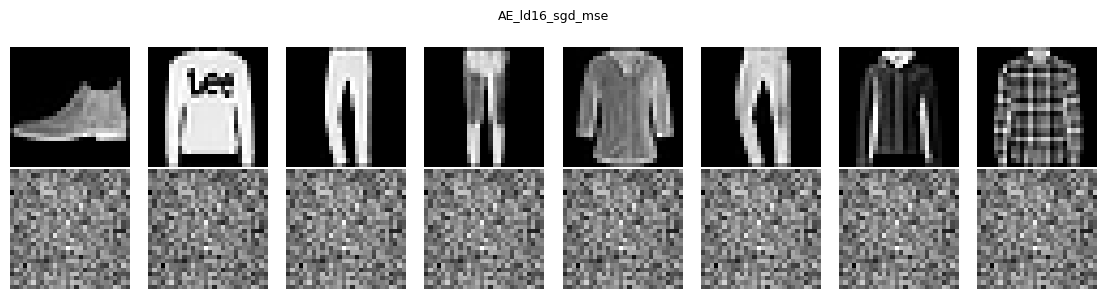

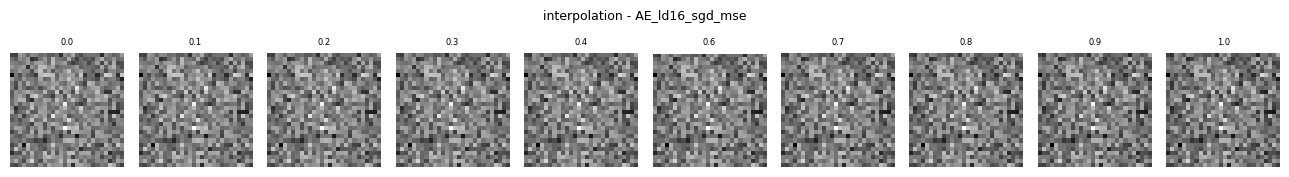

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.16814
train_loss,0.16893
val_loss,0.16877



starting: AE_ld16_rmsprop_bce


  epoch 1/5  train=0.3610  val=0.3262
  epoch 2/5  train=0.3181  val=0.3102
  epoch 3/5  train=0.3078  val=0.3084
  epoch 4/5  train=0.3018  val=0.2989
  epoch 5/5  train=0.2976  val=0.2984
  test_loss=0.3000


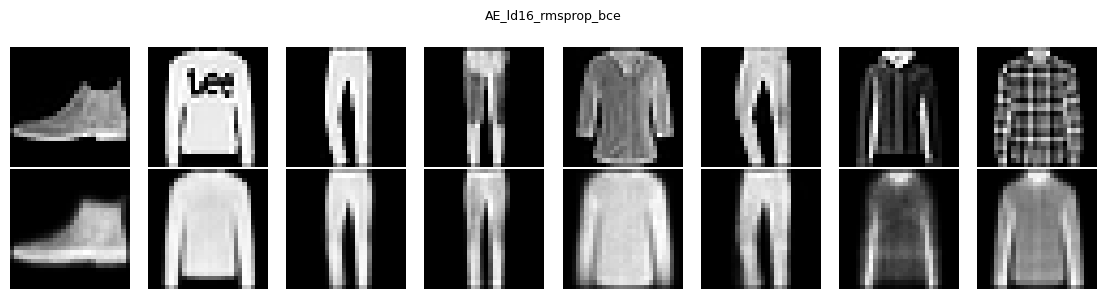

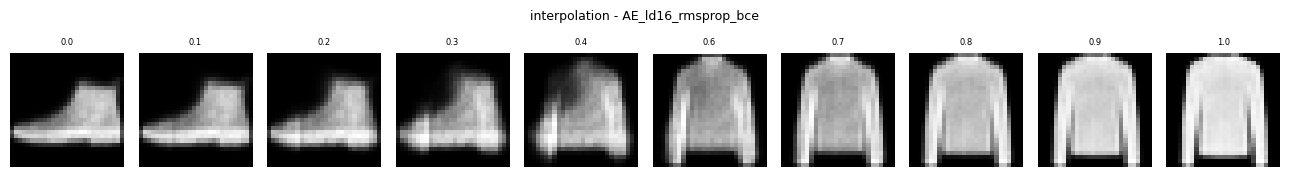

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▄▄▁▁
epoch,5
test_loss,0.29999
train_loss,0.29761
val_loss,0.29841



starting: AE_ld16_rmsprop_mse


  epoch 1/5  train=0.0386  val=0.0265
  epoch 2/5  train=0.0251  val=0.0221
  epoch 3/5  train=0.0220  val=0.0209
  epoch 4/5  train=0.0201  val=0.0190
  epoch 5/5  train=0.0184  val=0.0176
  test_loss=0.0177


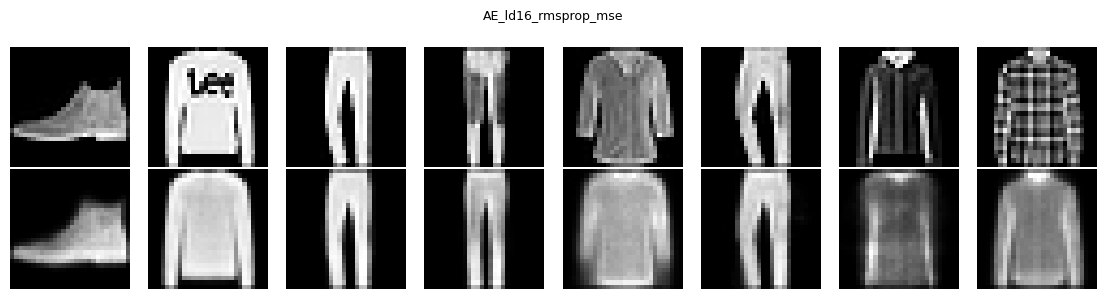

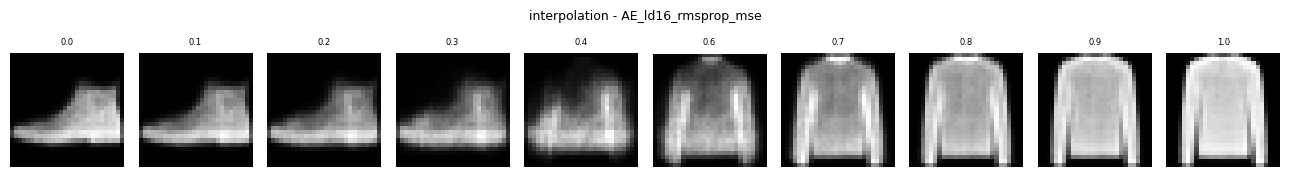

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▂▁
val_loss,█▅▄▂▁
epoch,5
test_loss,0.01766
train_loss,0.01842
val_loss,0.01762



starting: AE_ld32_adam_bce


  epoch 1/5  train=0.3478  val=0.3060
  epoch 2/5  train=0.2993  val=0.2951
  epoch 3/5  train=0.2917  val=0.2894
  epoch 4/5  train=0.2869  val=0.2861
  epoch 5/5  train=0.2832  val=0.2819
  test_loss=0.2835


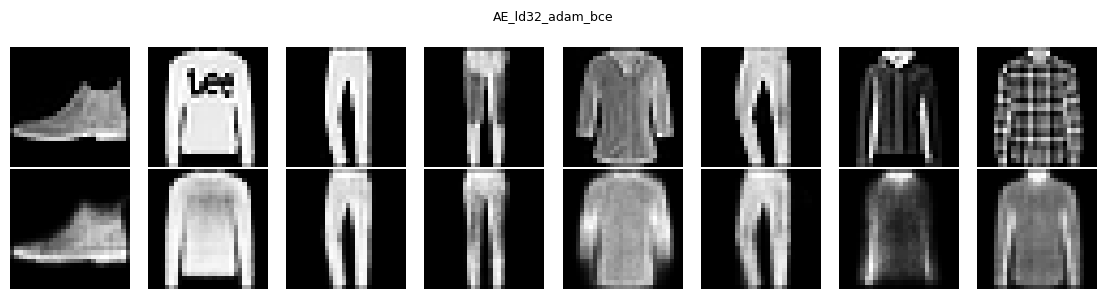

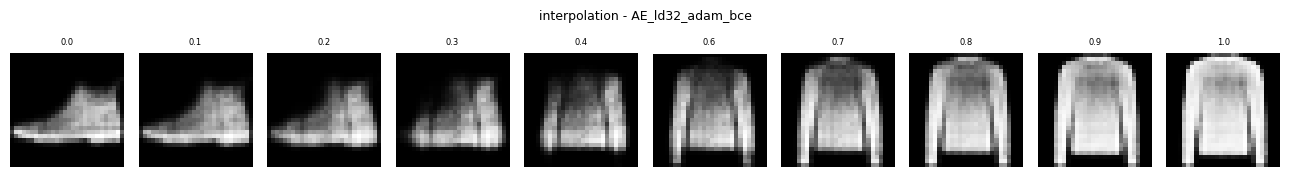

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▅▃▂▁
epoch,5
test_loss,0.2835
train_loss,0.28324
val_loss,0.28195



starting: AE_ld32_adam_mse


  epoch 1/5  train=0.0351  val=0.0210
  epoch 2/5  train=0.0189  val=0.0176
  epoch 3/5  train=0.0165  val=0.0157
  epoch 4/5  train=0.0147  val=0.0143
  epoch 5/5  train=0.0135  val=0.0131
  test_loss=0.0131


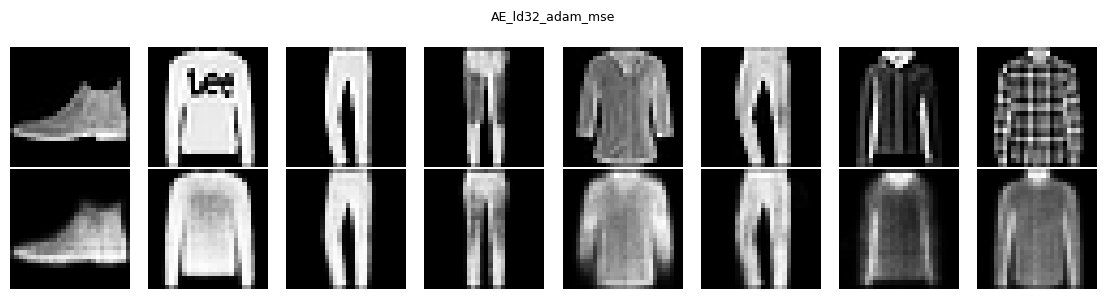

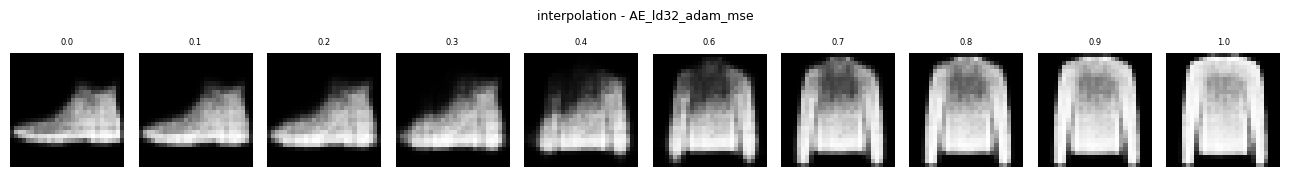

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▅▃▂▁
epoch,5
test_loss,0.01308
train_loss,0.01346
val_loss,0.01305



starting: AE_ld32_sgd_bce


  epoch 1/5  train=0.6930  val=0.6926
  epoch 2/5  train=0.6921  val=0.6917
  epoch 3/5  train=0.6912  val=0.6908
  epoch 4/5  train=0.6904  val=0.6899
  epoch 5/5  train=0.6894  val=0.6890
  test_loss=0.6890


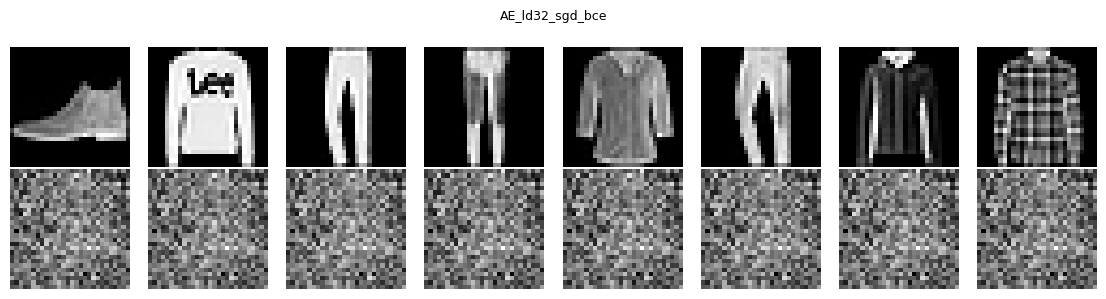

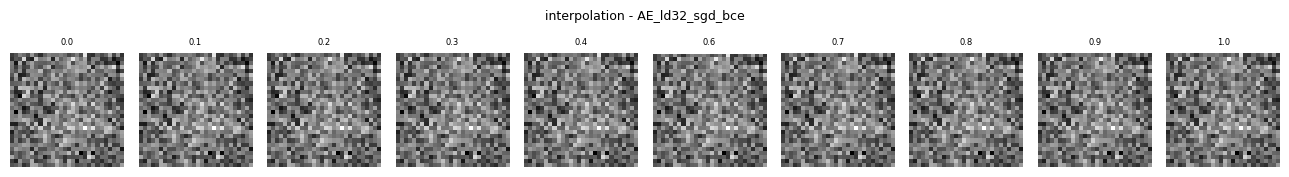

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.68899
train_loss,0.68945
val_loss,0.68899



starting: AE_ld32_sgd_mse


  epoch 1/5  train=0.1704  val=0.1703
  epoch 2/5  train=0.1702  val=0.1701
  epoch 3/5  train=0.1700  val=0.1698
  epoch 4/5  train=0.1697  val=0.1696
  epoch 5/5  train=0.1695  val=0.1693
  test_loss=0.1687


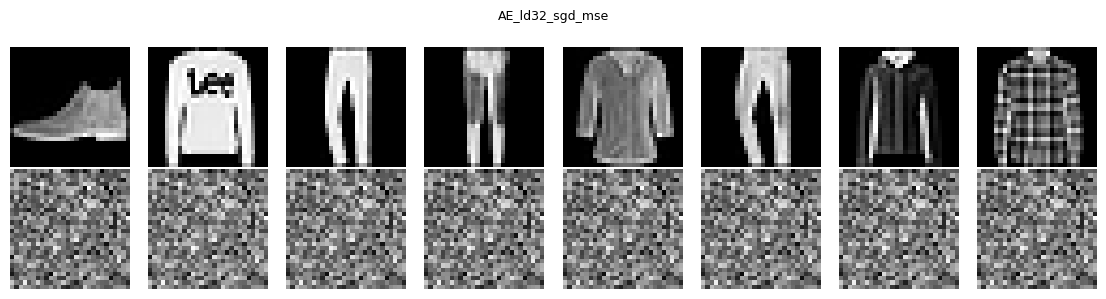

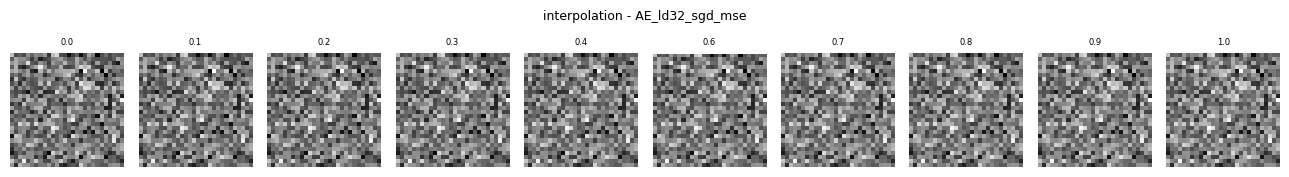

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▆▅▃▁
val_loss,█▆▅▃▁
epoch,5
test_loss,0.16872
train_loss,0.16947
val_loss,0.16935



starting: AE_ld32_rmsprop_bce


  epoch 1/5  train=0.3647  val=0.3323
  epoch 2/5  train=0.3184  val=0.3195
  epoch 3/5  train=0.3086  val=0.3049
  epoch 4/5  train=0.3025  val=0.3042
  epoch 5/5  train=0.2976  val=0.2955
  test_loss=0.2971


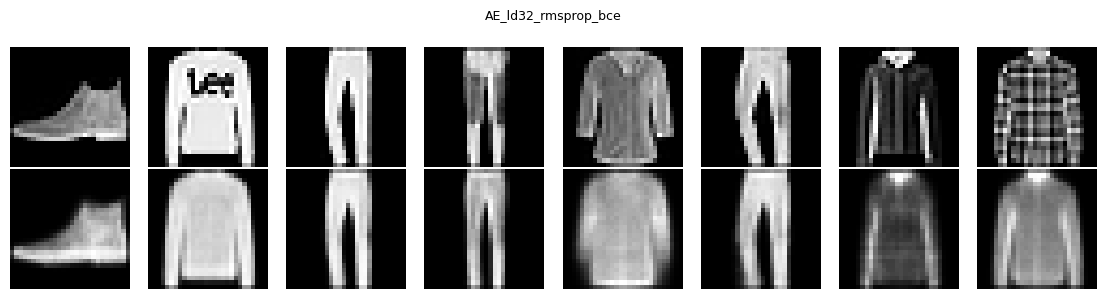

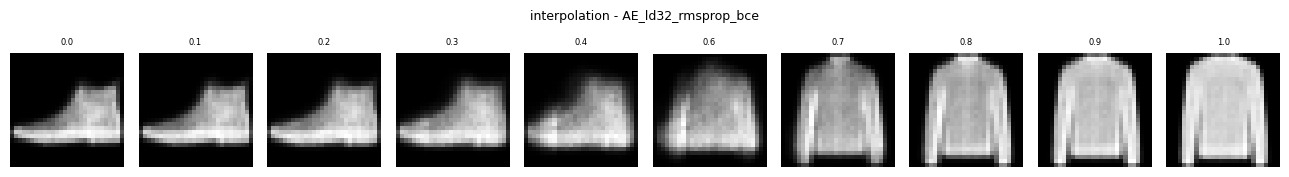

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▂▁
val_loss,█▆▃▃▁
epoch,5
test_loss,0.29705
train_loss,0.29764
val_loss,0.29551



starting: AE_ld32_rmsprop_mse


  epoch 1/5  train=0.0387  val=0.0259
  epoch 2/5  train=0.0243  val=0.0223
  epoch 3/5  train=0.0218  val=0.0214
  epoch 4/5  train=0.0201  val=0.0200
  epoch 5/5  train=0.0187  val=0.0179
  test_loss=0.0179


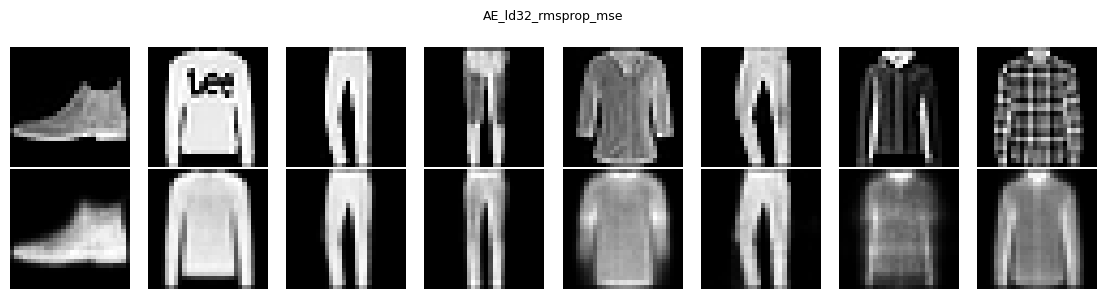

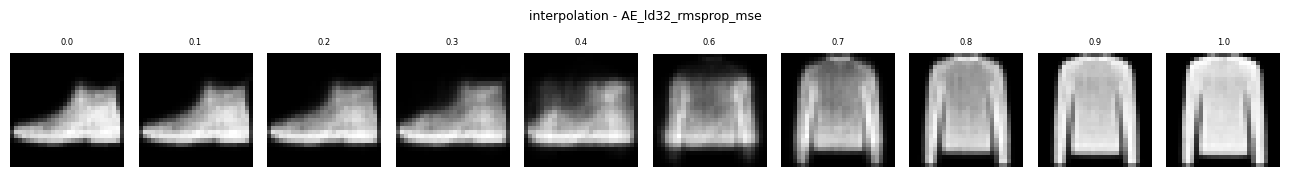

epoch,▁▃▅▆█
test_loss,▁
train_loss,█▃▂▁▁
val_loss,█▅▄▃▁
epoch,5
test_loss,0.01794
train_loss,0.01869
val_loss,0.01792



starting: VAE_ld2_adam_bce


  epoch 1/5  train=0.4951  recon=0.4948  kl=0.0002  val=0.4921
  epoch 2/5  train=0.4910  recon=0.4910  kl=0.0000  val=0.4921
  epoch 3/5  train=0.4909  recon=0.4908  kl=0.0000  val=0.4915
  epoch 4/5  train=0.4907  recon=0.4907  kl=0.0000  val=0.4913
  epoch 5/5  train=0.4907  recon=0.4907  kl=0.0000  val=0.4913
  test_loss=0.4913


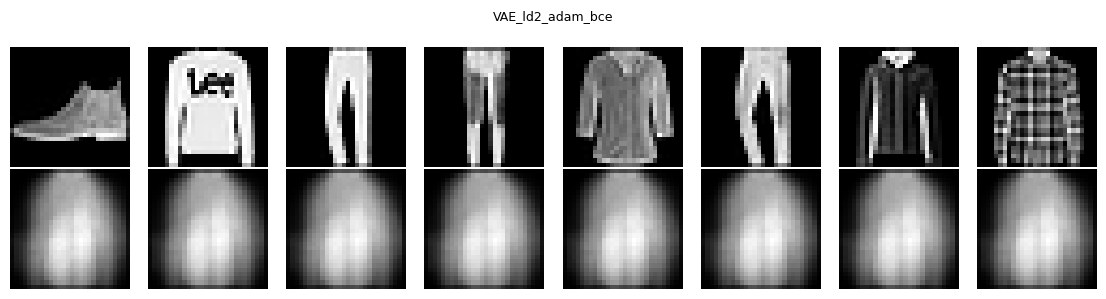

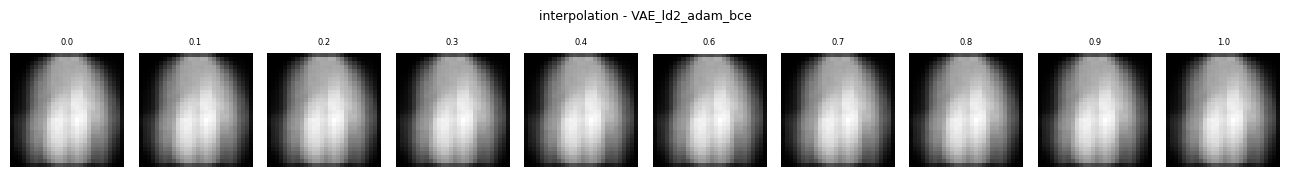

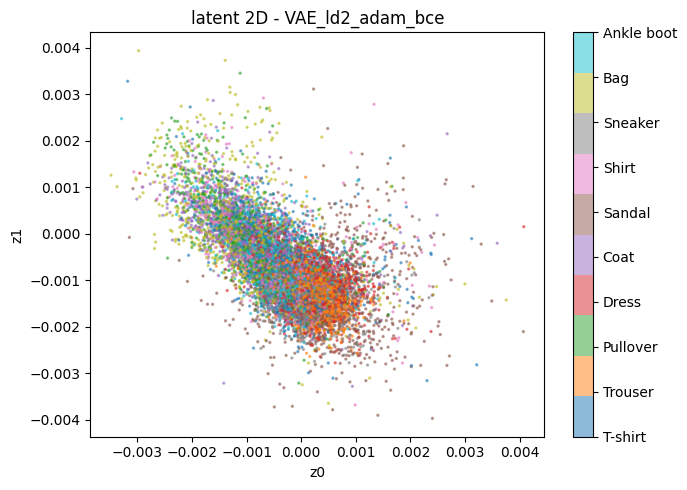

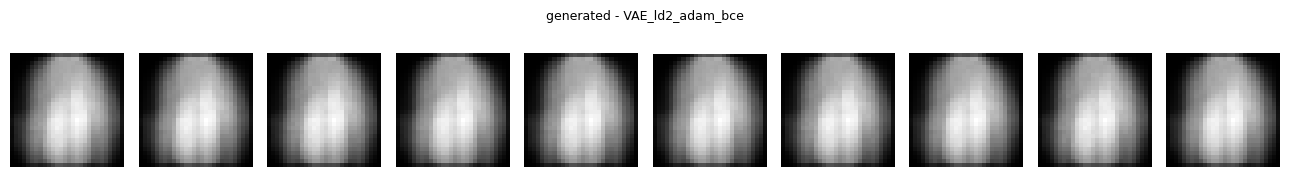

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▁▁▁▁
val_kl,▇█▂▃▁
val_loss,██▂▁▁
val_recon,██▂▁▁
epoch,5
test_loss,0.49131
train_kl,0.0



starting: VAE_ld2_adam_mse


  epoch 1/5  train=0.0890  recon=0.0888  kl=0.0002  val=0.0875
  epoch 2/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0876
  epoch 3/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0879
  epoch 4/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0875
  epoch 5/5  train=0.0871  recon=0.0871  kl=0.0000  val=0.0874
  test_loss=0.0868


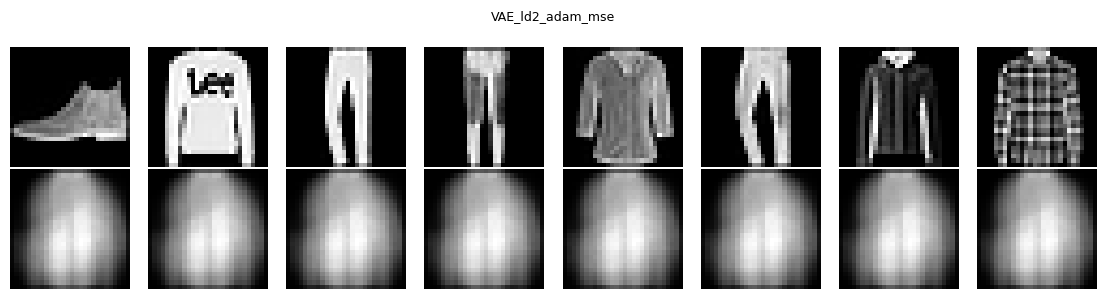

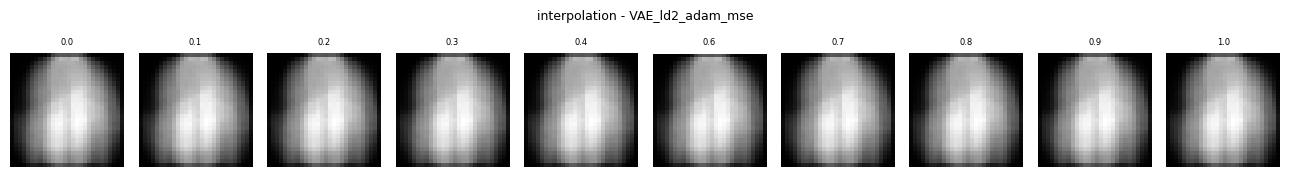

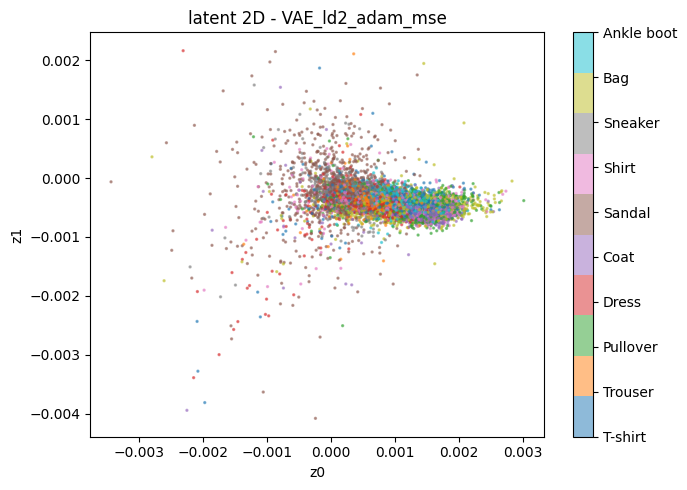

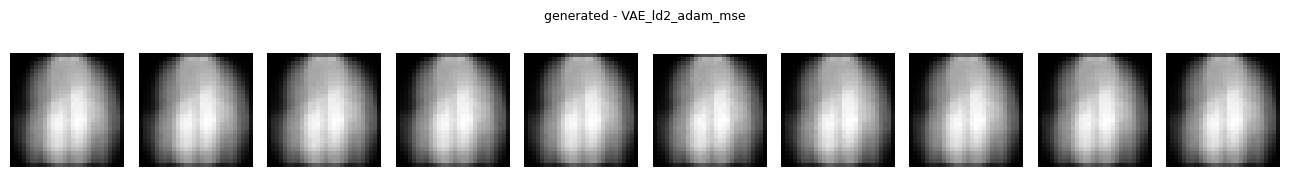

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▁▁▁▁
val_kl,█▃█▂▁
val_loss,▃▃█▂▁
val_recon,▃▃█▂▁
epoch,5
test_loss,0.08678
train_kl,0.0



starting: VAE_ld2_sgd_bce


  epoch 1/5  train=0.6925  recon=0.6920  kl=0.0005  val=0.6887
  epoch 2/5  train=0.6850  recon=0.6847  kl=0.0003  val=0.6811
  epoch 3/5  train=0.6768  recon=0.6766  kl=0.0002  val=0.6722
  epoch 4/5  train=0.6669  recon=0.6667  kl=0.0002  val=0.6611
  epoch 5/5  train=0.6542  recon=0.6540  kl=0.0002  val=0.6469
  test_loss=0.6470


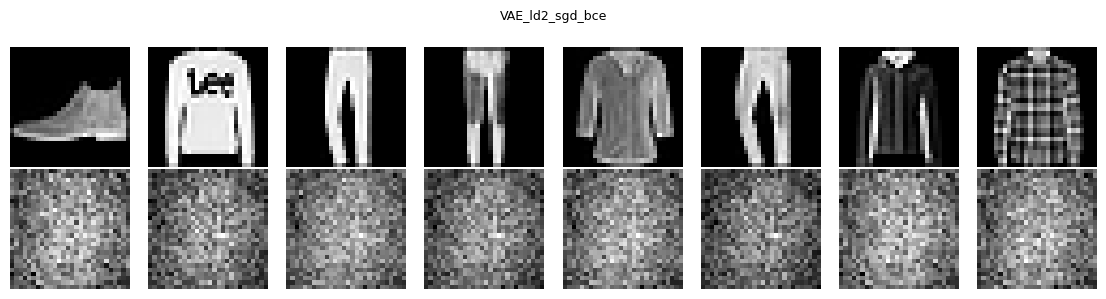

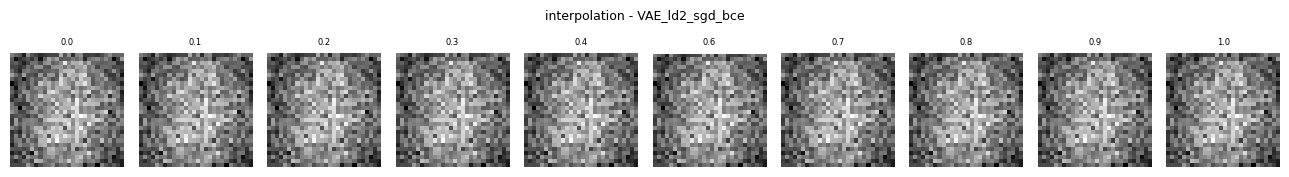

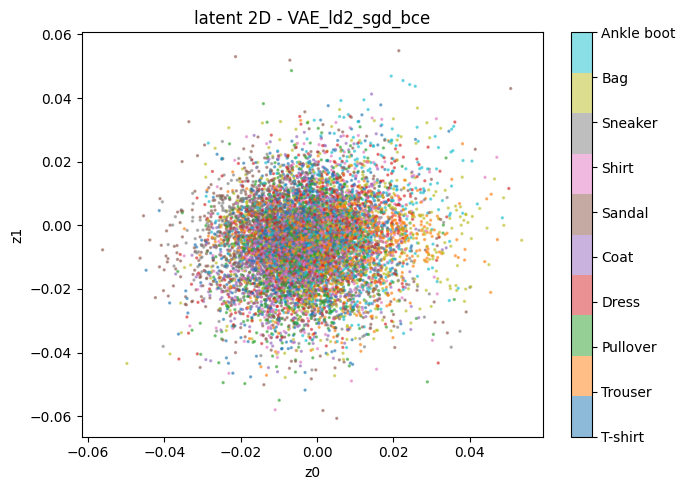

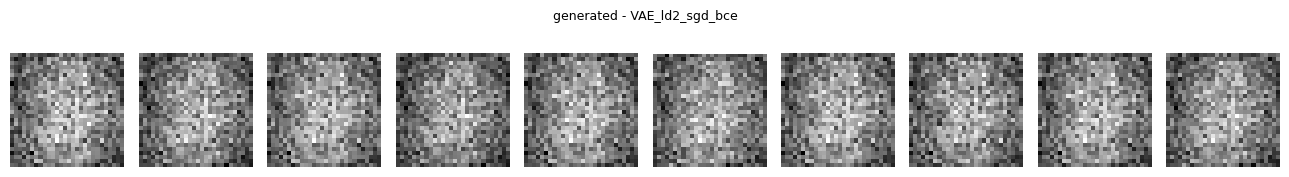

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▃▁▁▁
train_loss,█▇▅▃▁
train_recon,█▇▅▃▁
val_kl,█▃▂▁▂
val_loss,█▇▅▃▁
val_recon,█▇▅▃▁
epoch,5
test_loss,0.64698
train_kl,0.00019



starting: VAE_ld2_sgd_mse


  epoch 1/5  train=0.1707  recon=0.1703  kl=0.0004  val=0.1698
  epoch 2/5  train=0.1690  recon=0.1688  kl=0.0002  val=0.1682
  epoch 3/5  train=0.1674  recon=0.1672  kl=0.0002  val=0.1666
  epoch 4/5  train=0.1657  recon=0.1656  kl=0.0001  val=0.1649
  epoch 5/5  train=0.1640  recon=0.1638  kl=0.0001  val=0.1630
  test_loss=0.1624


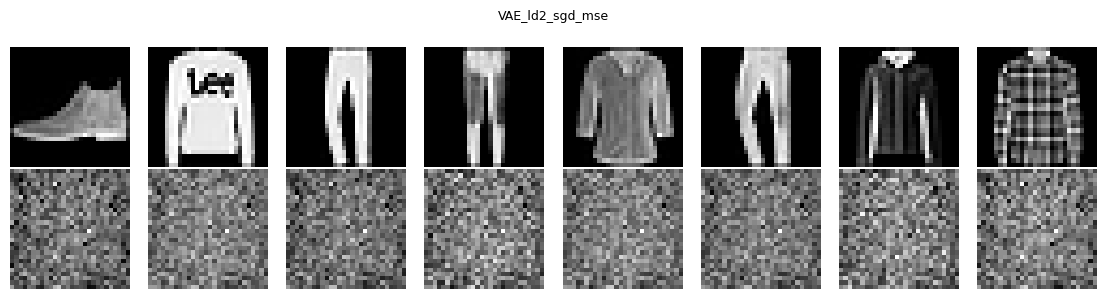

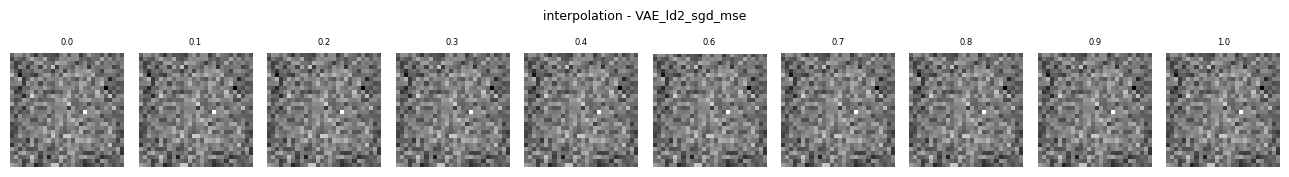

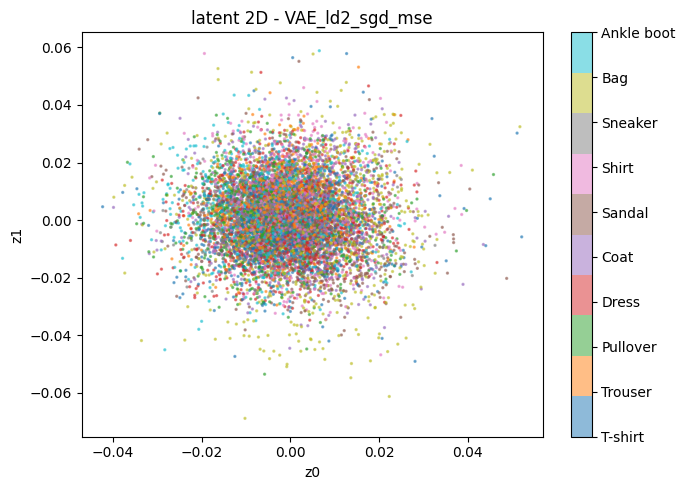

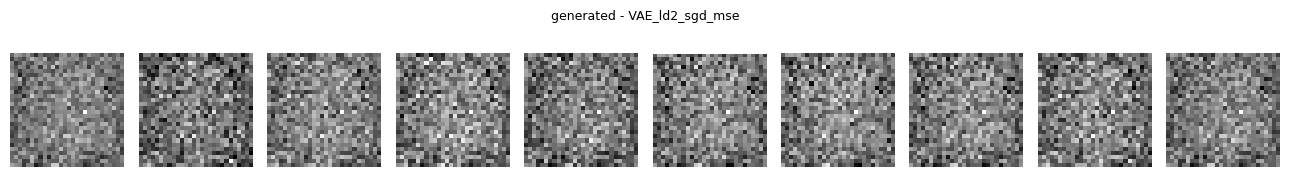

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▃▂▁▁
train_loss,█▆▅▃▁
train_recon,█▆▅▃▁
val_kl,█▅▃▂▁
val_loss,█▆▅▃▁
val_recon,█▆▅▃▁
epoch,5
test_loss,0.16241
train_kl,0.00014



starting: VAE_ld2_rmsprop_bce


  epoch 1/5  train=128407.2096  recon=0.5473  kl=128406.6648  val=0.4938
  epoch 2/5  train=0.4925  recon=0.4908  kl=0.0016  val=0.4935
  epoch 3/5  train=0.4925  recon=0.4906  kl=0.0020  val=0.4923
  epoch 4/5  train=0.4924  recon=0.4905  kl=0.0019  val=0.4929
  epoch 5/5  train=0.4920  recon=0.4904  kl=0.0016  val=0.4918
  test_loss=0.4916


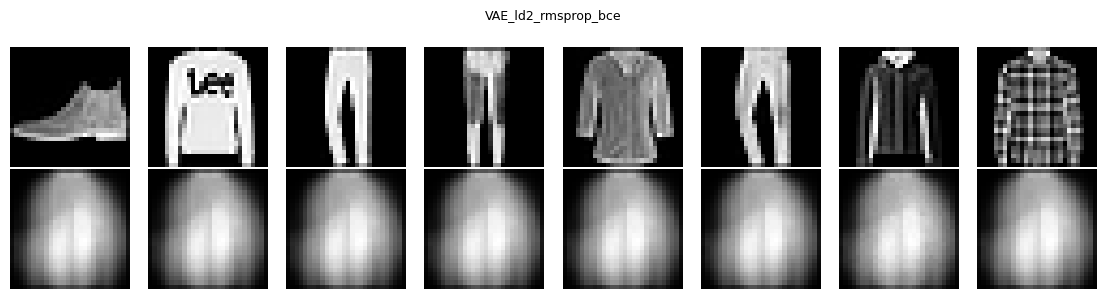

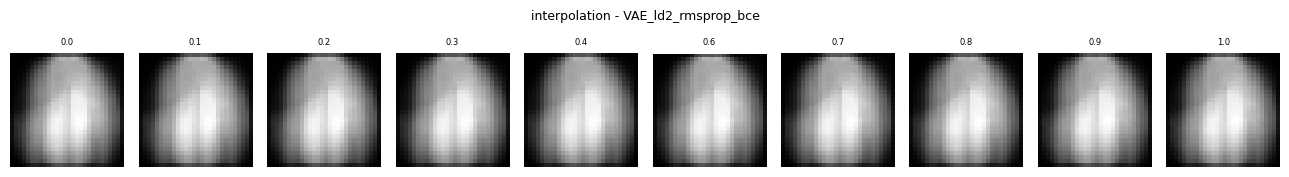

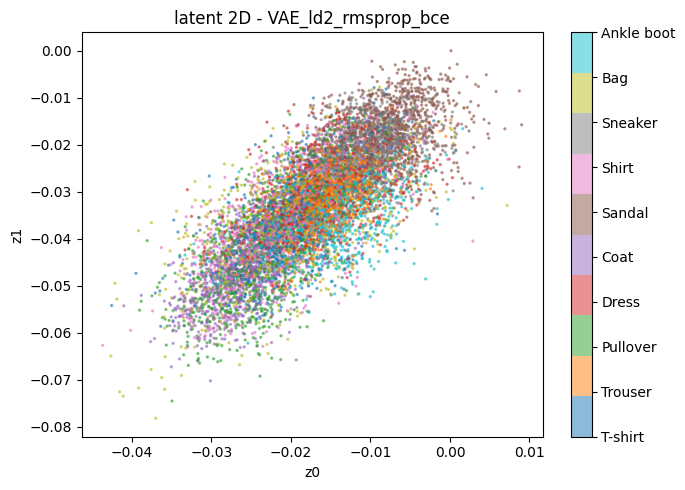

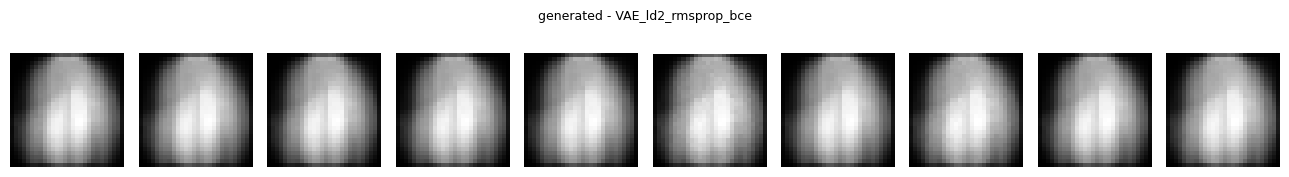

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▁▁▁▁
val_kl,██▃▄▁
val_loss,█▇▃▅▁
val_recon,█▂▂▇▁
epoch,5
test_loss,0.49163
train_kl,0.00156



starting: VAE_ld2_rmsprop_mse


  epoch 1/5  train=1478.4787  recon=0.0881  kl=1478.3906  val=0.0894
  epoch 2/5  train=0.0893  recon=0.0872  kl=0.0021  val=0.0883
  epoch 3/5  train=0.0899  recon=0.0871  kl=0.0028  val=0.0907
  epoch 4/5  train=0.0901  recon=0.0871  kl=0.0030  val=0.0877
  epoch 5/5  train=0.0893  recon=0.0871  kl=0.0022  val=0.0889
  test_loss=0.0883


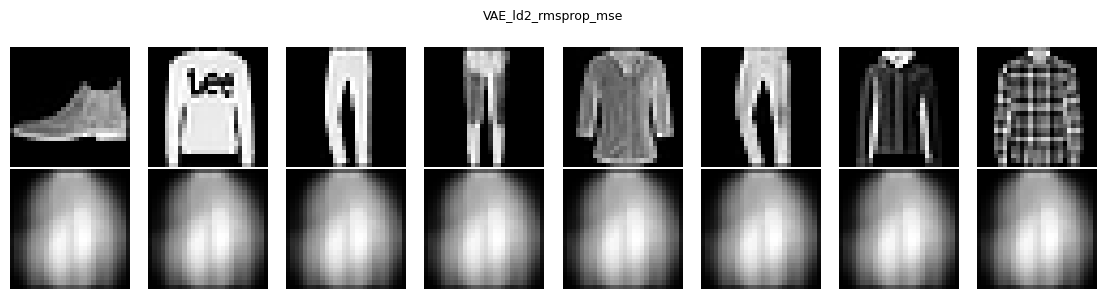

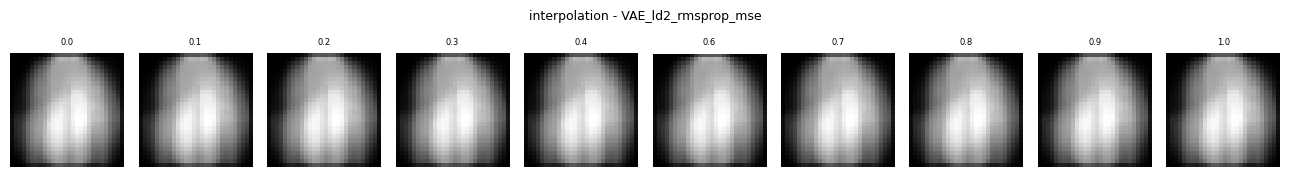

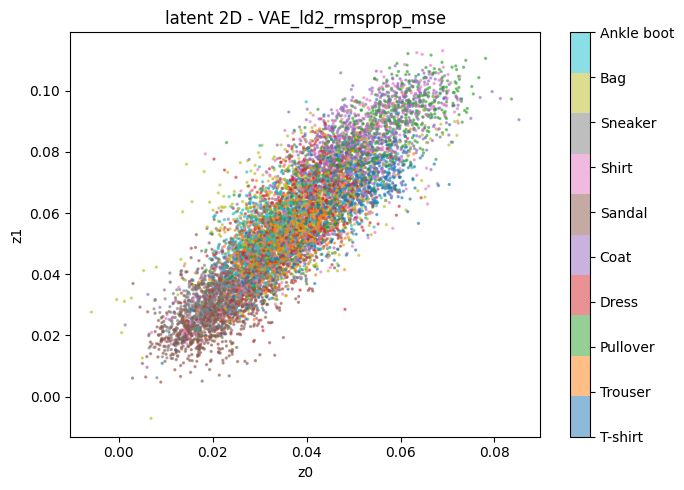

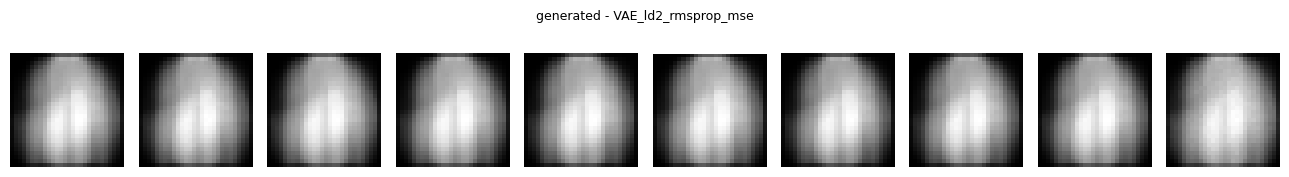

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▂▁▁▁
val_kl,▅▃█▁▄
val_loss,▅▃█▁▄
val_recon,█▂▂▃▁
epoch,5
test_loss,0.08827
train_kl,0.00221



starting: VAE_ld8_adam_bce


  epoch 1/5  train=0.4959  recon=0.4955  kl=0.0004  val=0.4920
  epoch 2/5  train=0.4911  recon=0.4910  kl=0.0001  val=0.4916
  epoch 3/5  train=0.4910  recon=0.4909  kl=0.0000  val=0.4917
  epoch 4/5  train=0.4909  recon=0.4909  kl=0.0000  val=0.4914
  epoch 5/5  train=0.4908  recon=0.4908  kl=0.0000  val=0.4913
  test_loss=0.4913


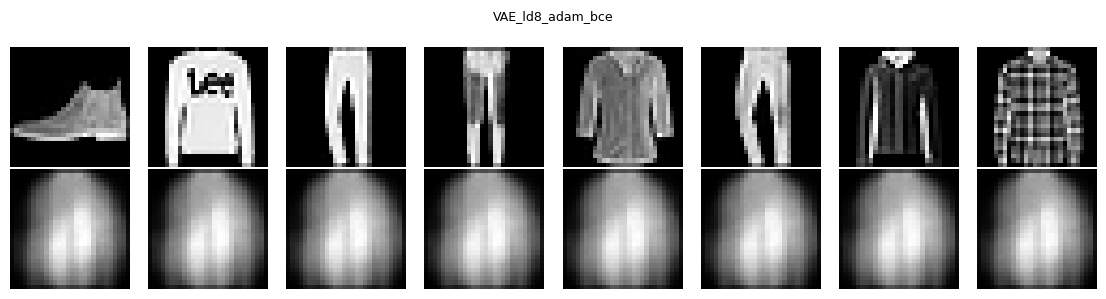

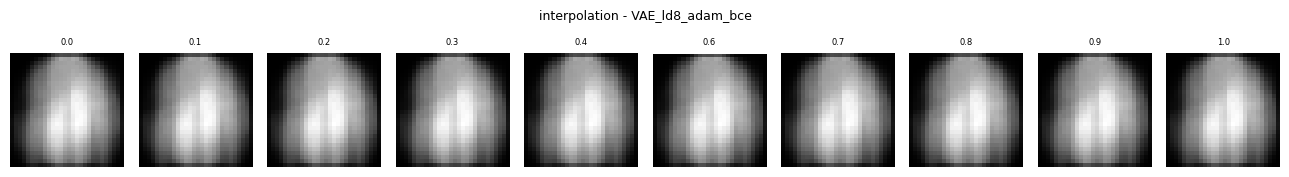

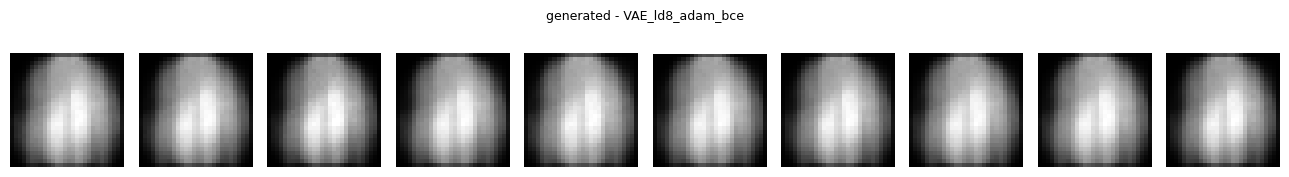

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▂▁▁▁
train_loss,█▁▁▁▁
train_recon,█▁▁▁▁
val_kl,█▅▂▂▁
val_loss,█▄▅▂▁
val_recon,█▄▅▂▁
epoch,5
test_loss,0.49133
train_kl,2e-05



starting: VAE_ld8_adam_mse


  epoch 1/5  train=0.0890  recon=0.0889  kl=0.0001  val=0.0880
  epoch 2/5  train=0.0873  recon=0.0872  kl=0.0000  val=0.0876
  epoch 3/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0876
  epoch 4/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0875
  epoch 5/5  train=0.0871  recon=0.0871  kl=0.0000  val=0.0874
  test_loss=0.0867


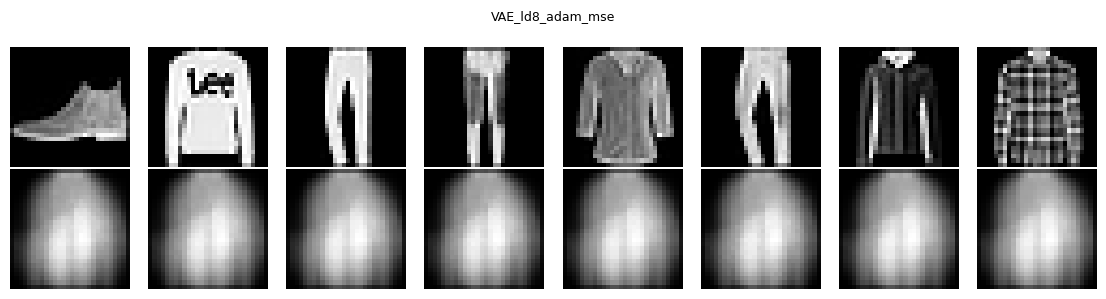

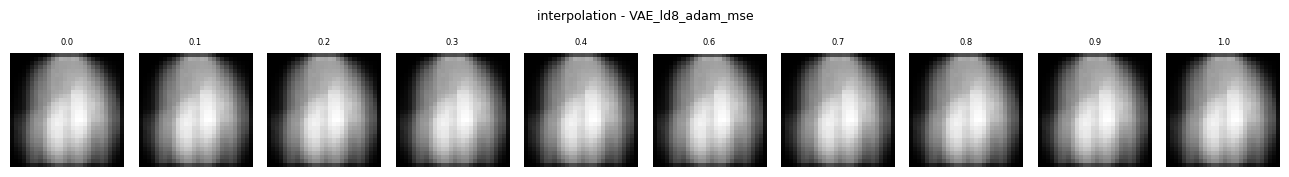

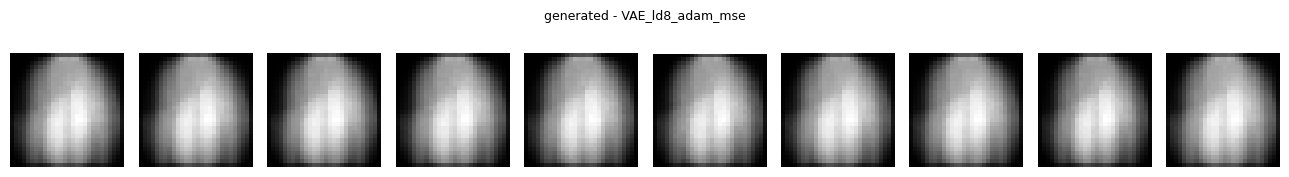

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▂▁▁▁
train_recon,█▂▁▁▁
val_kl,█▅▃▁▁
val_loss,█▄▃▂▁
val_recon,█▄▃▂▁
epoch,5
test_loss,0.08672
train_kl,0.0



starting: VAE_ld8_sgd_bce


  epoch 1/5  train=0.6931  recon=0.6922  kl=0.0009  val=0.6900
  epoch 2/5  train=0.6872  recon=0.6869  kl=0.0003  val=0.6845
  epoch 3/5  train=0.6816  recon=0.6813  kl=0.0003  val=0.6785
  epoch 4/5  train=0.6751  recon=0.6749  kl=0.0003  val=0.6716
  epoch 5/5  train=0.6674  recon=0.6672  kl=0.0003  val=0.6631
  test_loss=0.6632


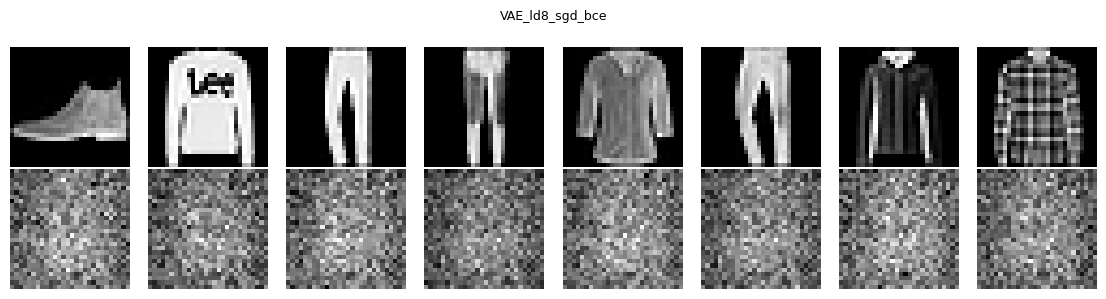

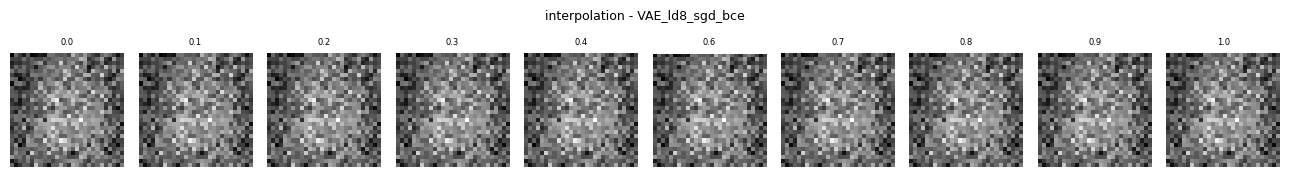

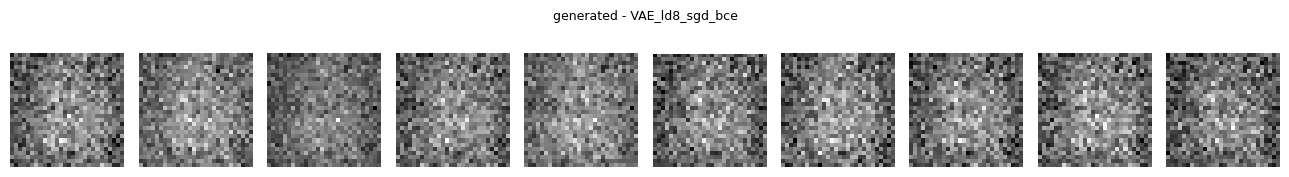

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▂▁▁▁
train_loss,█▆▅▃▁
train_recon,█▇▅▃▁
val_kl,█▃▂▁▂
val_loss,█▇▅▃▁
val_recon,█▇▅▃▁
epoch,5
test_loss,0.66323
train_kl,0.00026



starting: VAE_ld8_sgd_mse


  epoch 1/5  train=0.1715  recon=0.1708  kl=0.0008  val=0.1705
  epoch 2/5  train=0.1698  recon=0.1695  kl=0.0003  val=0.1692
  epoch 3/5  train=0.1686  recon=0.1683  kl=0.0003  val=0.1679
  epoch 4/5  train=0.1673  recon=0.1671  kl=0.0002  val=0.1667
  epoch 5/5  train=0.1660  recon=0.1658  kl=0.0002  val=0.1654
  test_loss=0.1647


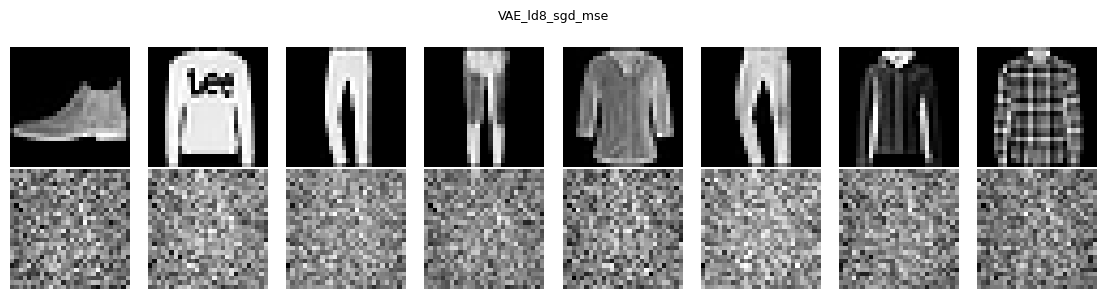

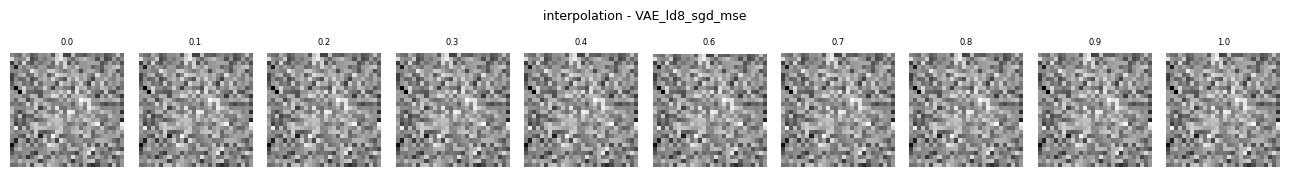

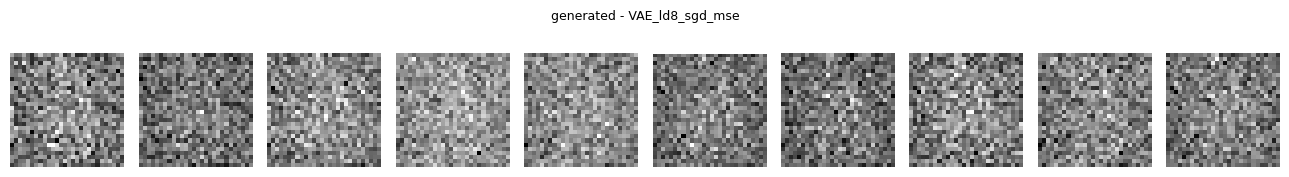

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▂▁▁▁
train_loss,█▆▄▃▁
train_recon,█▆▅▃▁
val_kl,█▄▃▂▁
val_loss,█▆▅▃▁
val_recon,█▆▅▃▁
epoch,5
test_loss,0.16475
train_kl,0.00023



starting: VAE_ld8_rmsprop_bce


  epoch 1/5  train=1204.6713  recon=0.5311  kl=1204.1403  val=0.4915
  epoch 2/5  train=0.4911  recon=0.4909  kl=0.0002  val=0.4914
  epoch 3/5  train=0.4908  recon=0.4907  kl=0.0001  val=0.4915
  epoch 4/5  train=0.4907  recon=0.4905  kl=0.0001  val=0.4915
  epoch 5/5  train=0.4905  recon=0.4904  kl=0.0001  val=0.4913
  test_loss=0.4912


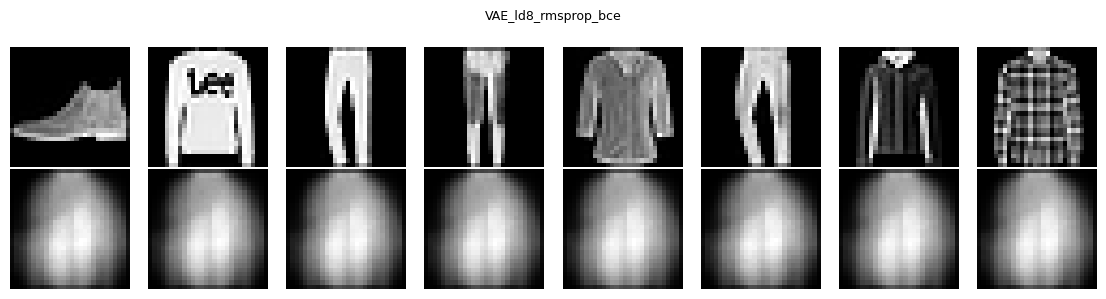

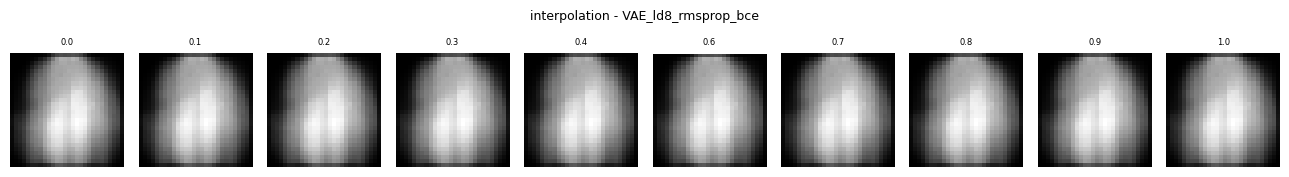

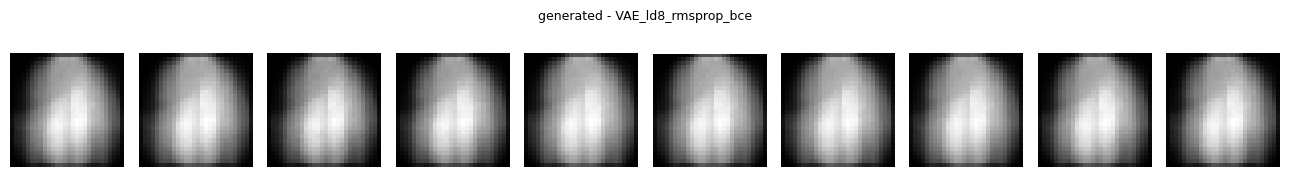

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▁▁▁▁
val_kl,█▇▃▂▁
val_loss,▇▅▇█▁
val_recon,▄▂▇█▁
epoch,5
test_loss,0.49121
train_kl,0.00011



starting: VAE_ld8_rmsprop_mse


  epoch 1/5  train=14.5792  recon=0.0882  kl=14.4910  val=0.0882
  epoch 2/5  train=0.0879  recon=0.0873  kl=0.0007  val=0.0883
  epoch 3/5  train=0.0877  recon=0.0872  kl=0.0005  val=0.0876
  epoch 4/5  train=0.0874  recon=0.0871  kl=0.0002  val=0.0876
  epoch 5/5  train=0.0872  recon=0.0871  kl=0.0001  val=0.0875
  test_loss=0.0868


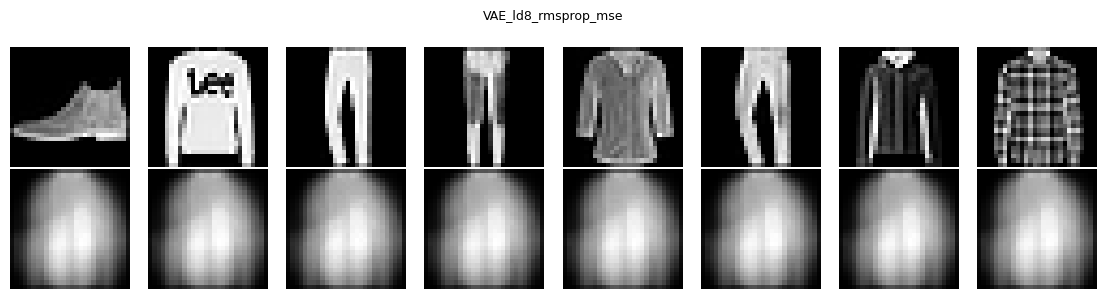

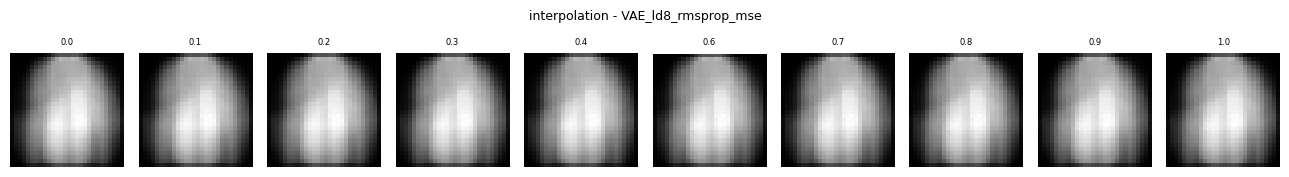

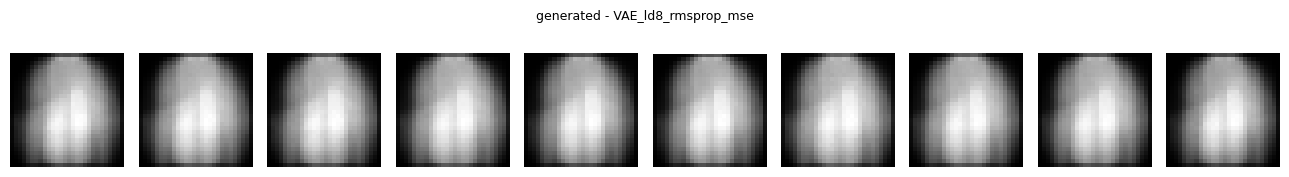

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▂▁▁▁
val_kl,▅█▂▃▁
val_loss,▇█▂▂▁
val_recon,█▂▂▁▂
epoch,5
test_loss,0.08685
train_kl,6e-05



starting: VAE_ld16_adam_bce


  epoch 1/5  train=0.4931  recon=0.4854  kl=0.0077  val=0.4864
  epoch 2/5  train=0.4809  recon=0.4485  kl=0.0324  val=0.4802
  epoch 3/5  train=0.4786  recon=0.4403  kl=0.0383  val=0.4788
  epoch 4/5  train=0.4769  recon=0.4314  kl=0.0455  val=0.4768
  epoch 5/5  train=0.4768  recon=0.4292  kl=0.0476  val=0.4771
  test_loss=0.4783


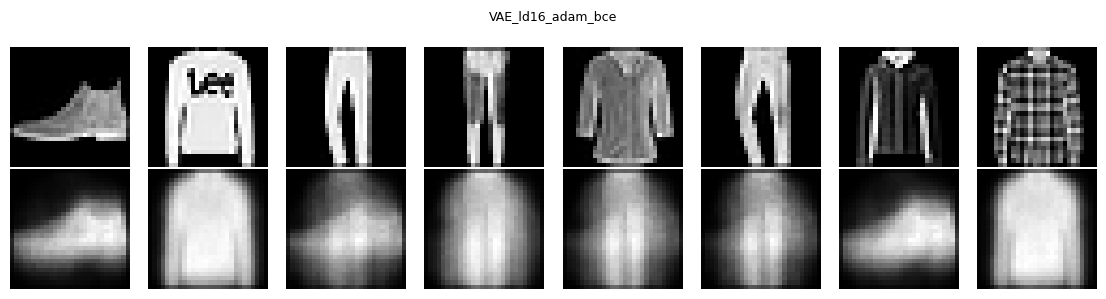

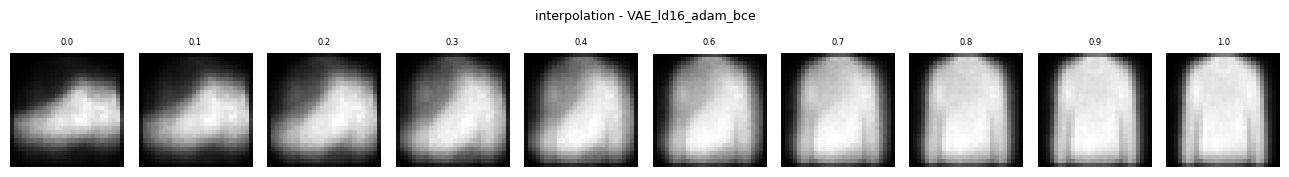

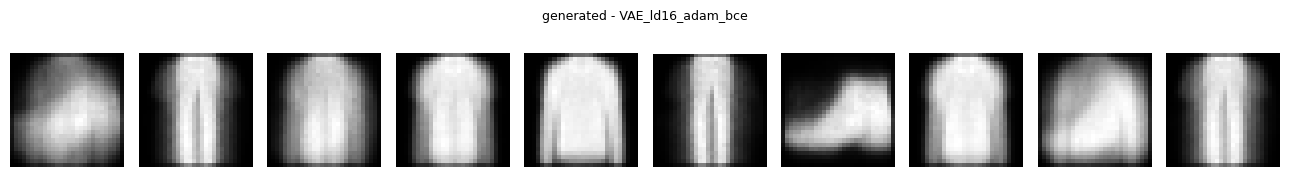

epoch,▁▃▅▆█
test_loss,▁
train_kl,▁▅▆██
train_loss,█▃▂▁▁
train_recon,█▃▂▁▁
val_kl,▁▅▇██
val_loss,█▃▂▁▁
val_recon,█▄▂▁▁
epoch,5
test_loss,0.47826
train_kl,0.04763



starting: VAE_ld16_adam_mse


  epoch 1/5  train=0.0891  recon=0.0889  kl=0.0002  val=0.0877
  epoch 2/5  train=0.0873  recon=0.0873  kl=0.0000  val=0.0875
  epoch 3/5  train=0.0873  recon=0.0873  kl=0.0000  val=0.0876
  epoch 4/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0874
  epoch 5/5  train=0.0872  recon=0.0872  kl=0.0000  val=0.0875
  test_loss=0.0868


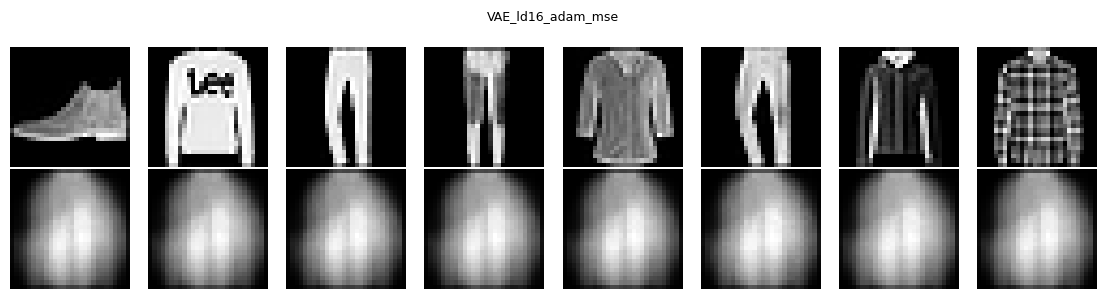

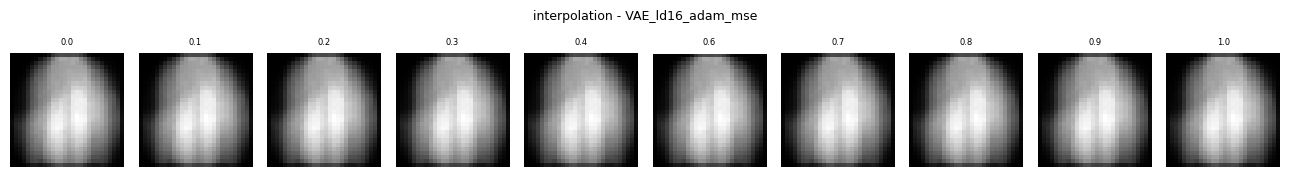

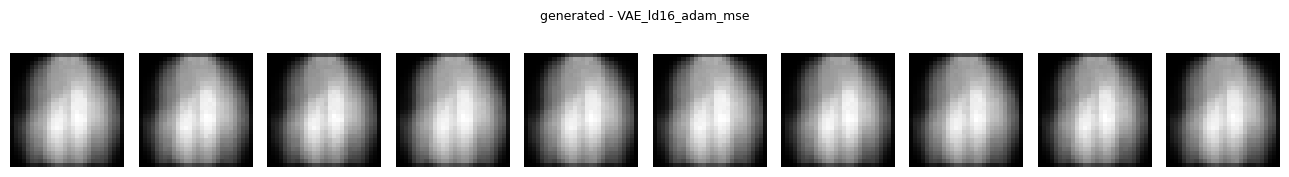

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▃▂▁▁
train_loss,█▂▁▁▁
train_recon,█▁▁▁▁
val_kl,█▃▂▁▁
val_loss,█▃▅▁▂
val_recon,█▃▆▁▃
epoch,5
test_loss,0.08681
train_kl,1e-05



starting: VAE_ld16_sgd_bce


  epoch 1/5  train=0.6934  recon=0.6920  kl=0.0014  val=0.6905
  epoch 2/5  train=0.6881  recon=0.6875  kl=0.0005  val=0.6857
  epoch 3/5  train=0.6832  recon=0.6828  kl=0.0004  val=0.6807
  epoch 4/5  train=0.6779  recon=0.6776  kl=0.0003  val=0.6750
  epoch 5/5  train=0.6717  recon=0.6714  kl=0.0003  val=0.6683
  test_loss=0.6683


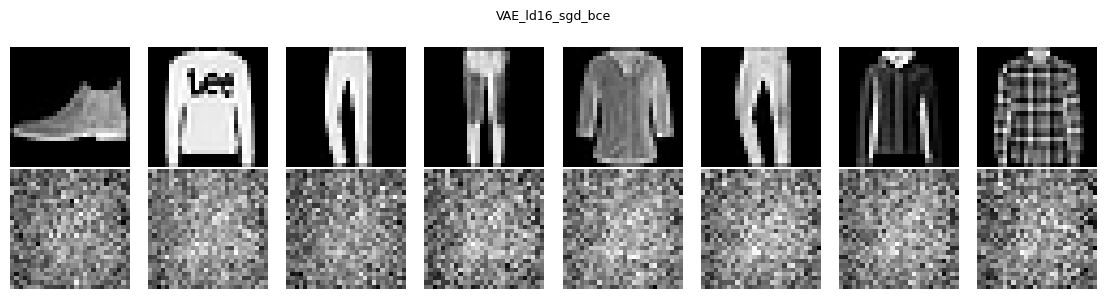

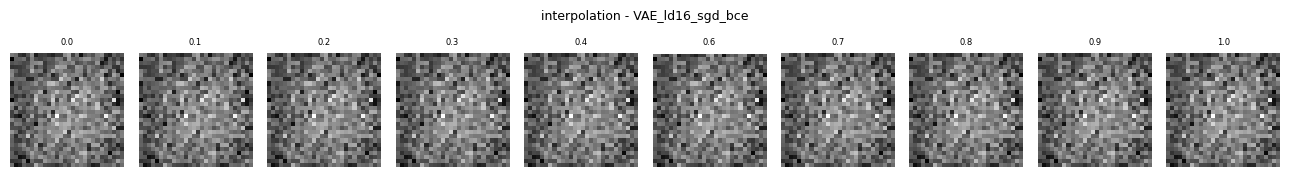

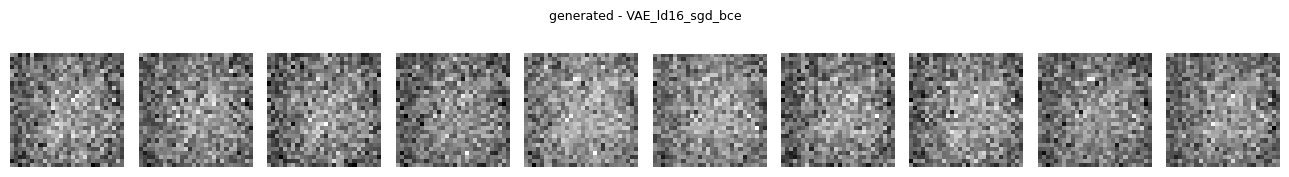

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▂▁▁▁
train_loss,█▆▅▃▁
train_recon,█▆▅▃▁
val_kl,█▃▂▁▁
val_loss,█▆▅▃▁
val_recon,█▇▅▃▁
epoch,5
test_loss,0.66829
train_kl,0.00031



starting: VAE_ld16_sgd_mse


  epoch 1/5  train=0.1713  recon=0.1701  kl=0.0011  val=0.1702
  epoch 2/5  train=0.1695  recon=0.1691  kl=0.0005  val=0.1689
  epoch 3/5  train=0.1684  recon=0.1680  kl=0.0004  val=0.1678
  epoch 4/5  train=0.1673  recon=0.1669  kl=0.0003  val=0.1667
  epoch 5/5  train=0.1661  recon=0.1658  kl=0.0003  val=0.1655
  test_loss=0.1649


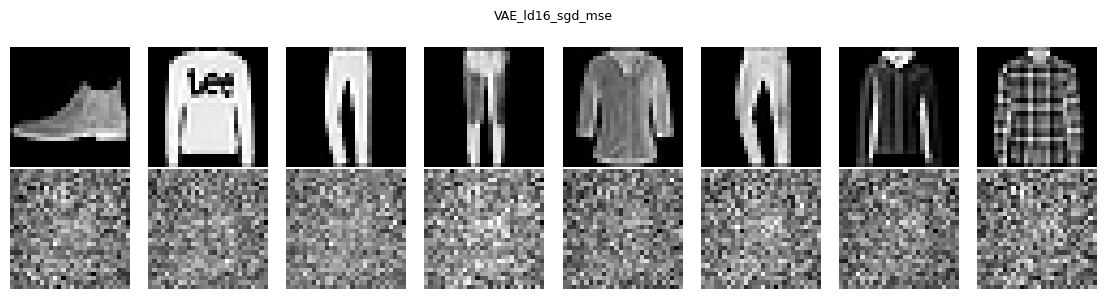

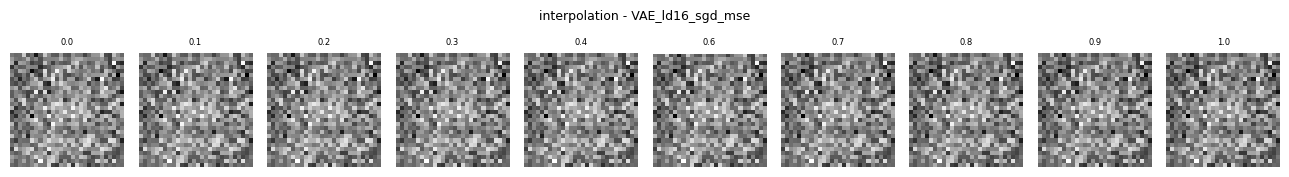

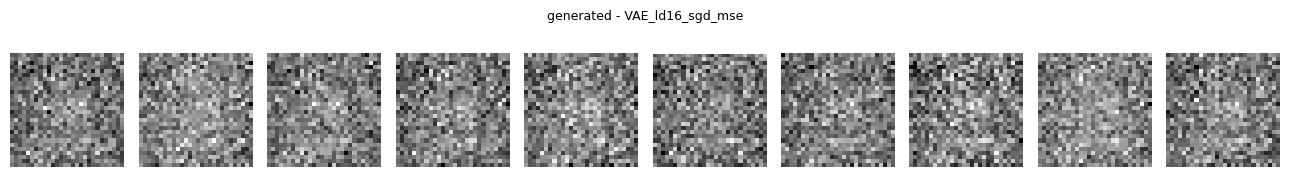

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▂▂▁▁
train_loss,█▆▄▃▁
train_recon,█▆▅▃▁
val_kl,█▄▂▁▁
val_loss,█▆▄▃▁
val_recon,█▆▅▃▁
epoch,5
test_loss,0.16492
train_kl,0.00029



starting: VAE_ld16_rmsprop_bce


  epoch 1/5  train=0.7283  recon=0.5007  kl=0.2275  val=0.4913
  epoch 2/5  train=0.4878  recon=0.4756  kl=0.0122  val=0.4892
  epoch 3/5  train=0.4840  recon=0.4608  kl=0.0232  val=0.4823
  epoch 4/5  train=0.4809  recon=0.4485  kl=0.0324  val=0.4810
  epoch 5/5  train=0.4799  recon=0.4440  kl=0.0359  val=0.4795
  test_loss=0.4790


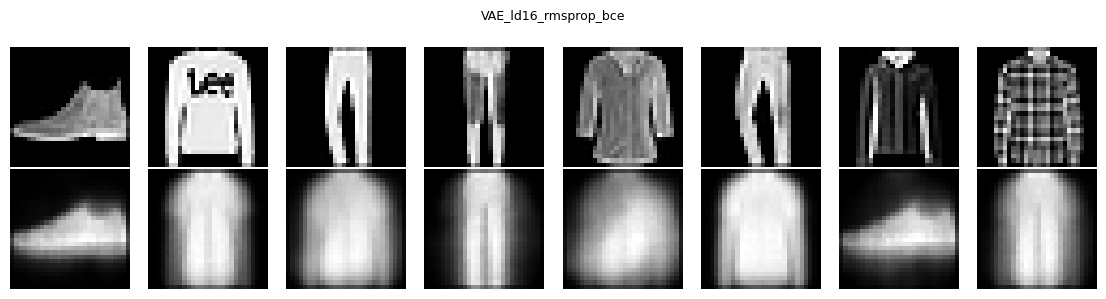

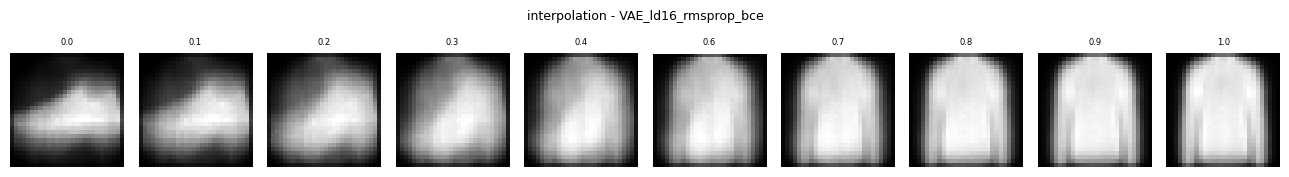

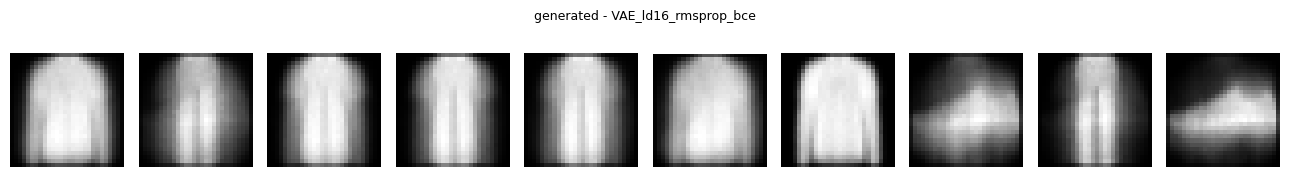

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▂▂
train_loss,█▁▁▁▁
train_recon,█▅▃▂▁
val_kl,▁▄▆▇█
val_loss,█▇▃▂▁
val_recon,█▅▃▂▁
epoch,5
test_loss,0.47896
train_kl,0.03586



starting: VAE_ld16_rmsprop_mse


  epoch 1/5  train=1.2211  recon=0.0882  kl=1.1329  val=0.0879
  epoch 2/5  train=0.0876  recon=0.0873  kl=0.0003  val=0.0877
  epoch 3/5  train=0.0874  recon=0.0872  kl=0.0002  val=0.0875
  epoch 4/5  train=0.0872  recon=0.0872  kl=0.0001  val=0.0875
  epoch 5/5  train=0.0872  recon=0.0871  kl=0.0000  val=0.0874
  test_loss=0.0868


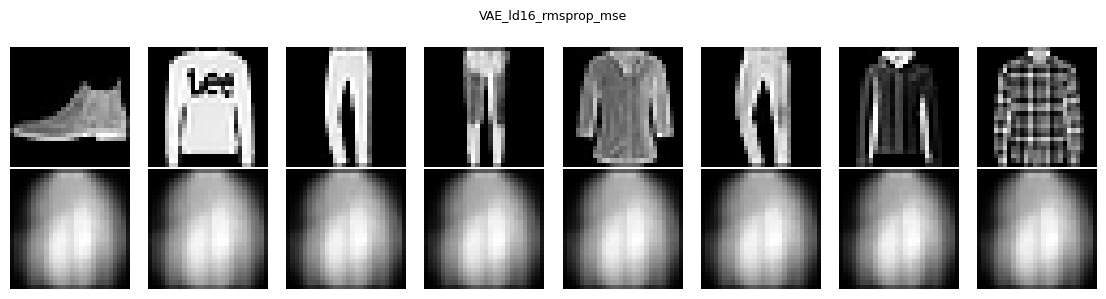

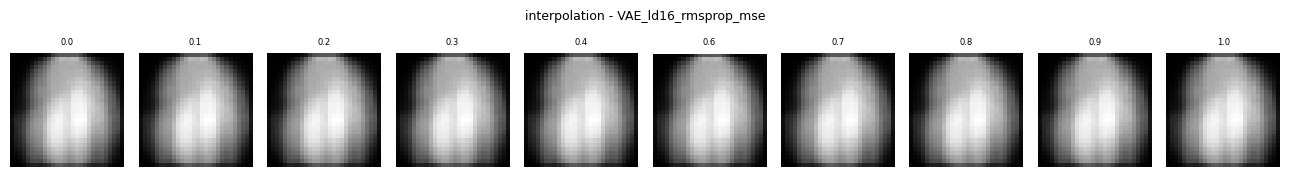

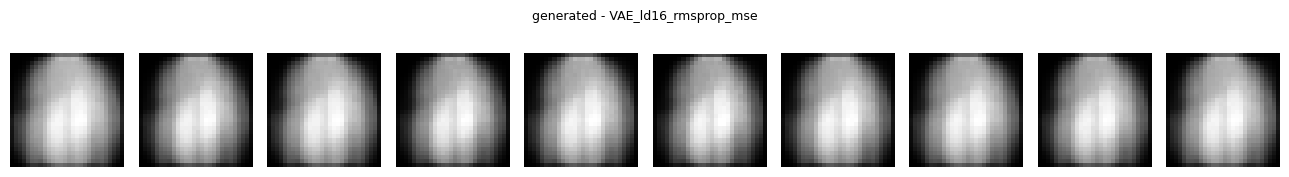

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▂▁▁▁
val_kl,█▃▃▁▁
val_loss,█▆▃▂▁
val_recon,▂█▂▂▁
epoch,5
test_loss,0.0868
train_kl,3e-05



starting: VAE_ld32_adam_bce


  epoch 1/5  train=0.4817  recon=0.4638  kl=0.0179  val=0.4614
  epoch 2/5  train=0.4486  recon=0.4043  kl=0.0442  val=0.4425
  epoch 3/5  train=0.4389  recon=0.3859  kl=0.0531  val=0.4398
  epoch 4/5  train=0.4373  recon=0.3825  kl=0.0548  val=0.4380
  epoch 5/5  train=0.4366  recon=0.3809  kl=0.0557  val=0.4386
  test_loss=0.4383


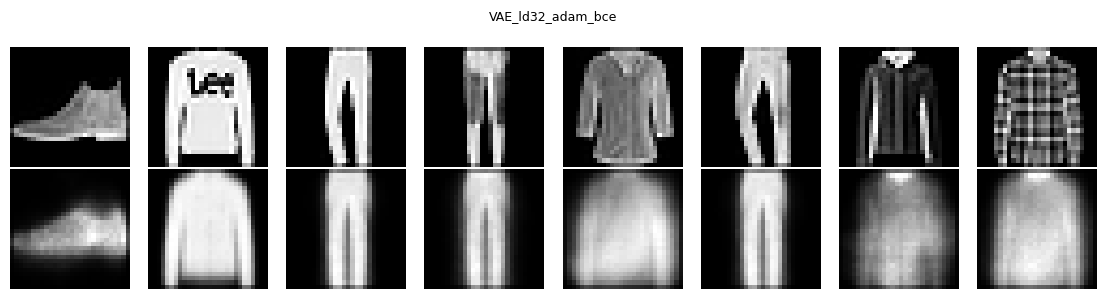

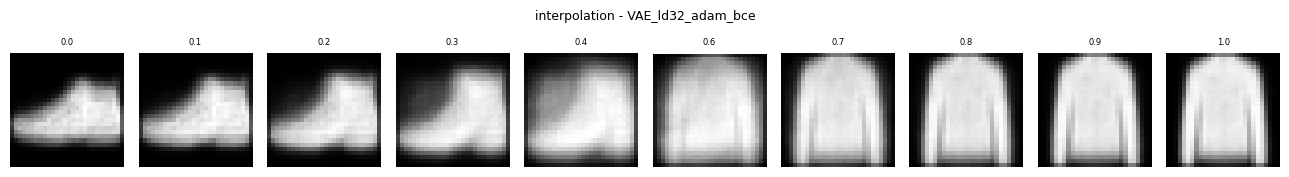

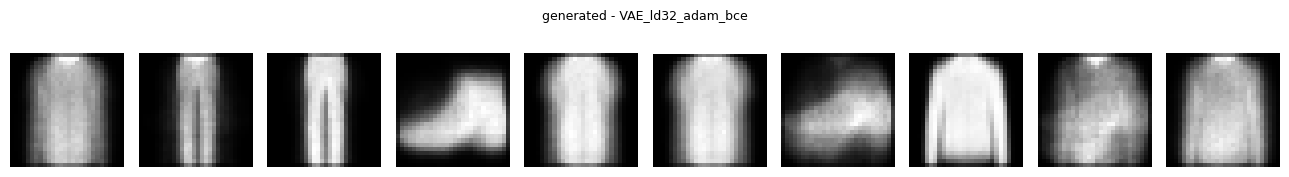

epoch,▁▃▅▆█
test_loss,▁
train_kl,▁▆███
train_loss,█▃▁▁▁
train_recon,█▃▁▁▁
val_kl,▁▆▆██
val_loss,█▂▂▁▁
val_recon,█▃▂▁▁
epoch,5
test_loss,0.43828
train_kl,0.05567



starting: VAE_ld32_adam_mse


  epoch 1/5  train=0.0889  recon=0.0879  kl=0.0010  val=0.0868
  epoch 2/5  train=0.0864  recon=0.0819  kl=0.0045  val=0.0864
  epoch 3/5  train=0.0861  recon=0.0813  kl=0.0048  val=0.0864
  epoch 4/5  train=0.0859  recon=0.0807  kl=0.0052  val=0.0867
  epoch 5/5  train=0.0857  recon=0.0801  kl=0.0056  val=0.0861
  test_loss=0.0853


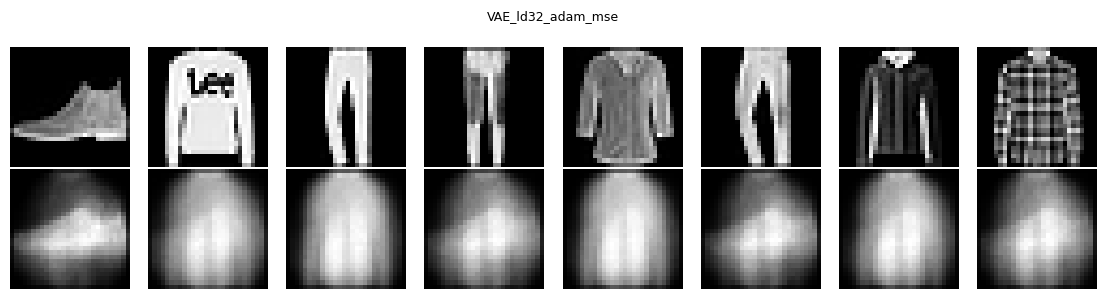

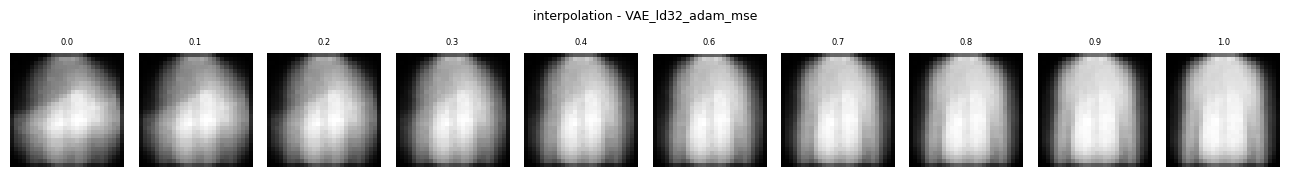

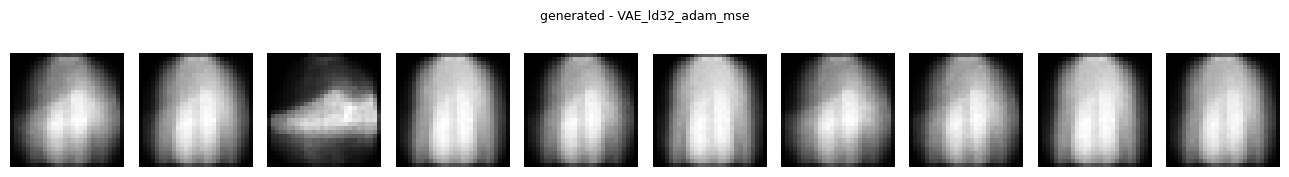

epoch,▁▃▅▆█
test_loss,▁
train_kl,▁▆▇▇█
train_loss,█▂▂▁▁
train_recon,█▃▂▁▁
val_kl,▂▁▃▄█
val_loss,█▄▄▇▁
val_recon,██▆▆▁
epoch,5
test_loss,0.08528
train_kl,0.00558



starting: VAE_ld32_sgd_bce


  epoch 1/5  train=0.6949  recon=0.6932  kl=0.0017  val=0.6923
  epoch 2/5  train=0.6899  recon=0.6890  kl=0.0009  val=0.6876
  epoch 3/5  train=0.6853  recon=0.6847  kl=0.0006  val=0.6830
  epoch 4/5  train=0.6805  recon=0.6800  kl=0.0005  val=0.6779
  epoch 5/5  train=0.6750  recon=0.6746  kl=0.0004  val=0.6721
  test_loss=0.6720


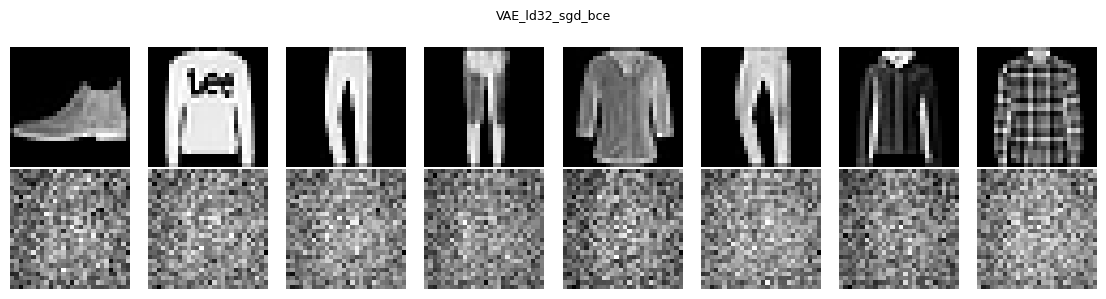

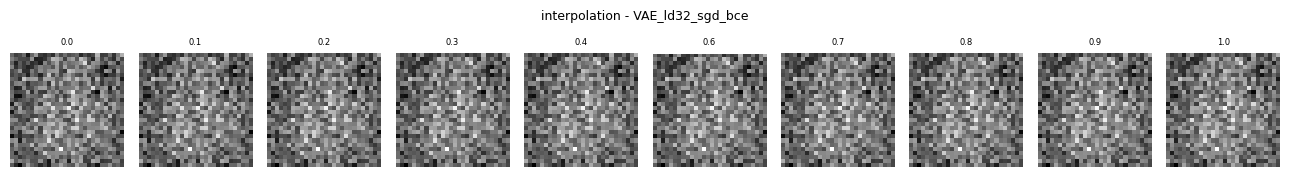

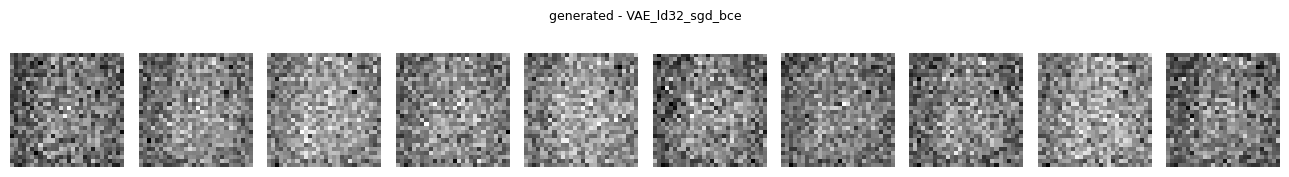

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▃▂▁▁
train_loss,█▆▅▃▁
train_recon,█▆▅▃▁
val_kl,█▄▂▁▁
val_loss,█▆▅▃▁
val_recon,█▆▅▃▁
epoch,5
test_loss,0.67204
train_kl,0.00042



starting: VAE_ld32_sgd_mse


  epoch 1/5  train=0.1722  recon=0.1705  kl=0.0016  val=0.1712
  epoch 2/5  train=0.1704  recon=0.1696  kl=0.0008  val=0.1698
  epoch 3/5  train=0.1692  recon=0.1686  kl=0.0006  val=0.1687
  epoch 4/5  train=0.1681  recon=0.1677  kl=0.0004  val=0.1676
  epoch 5/5  train=0.1670  recon=0.1667  kl=0.0004  val=0.1665
  test_loss=0.1659


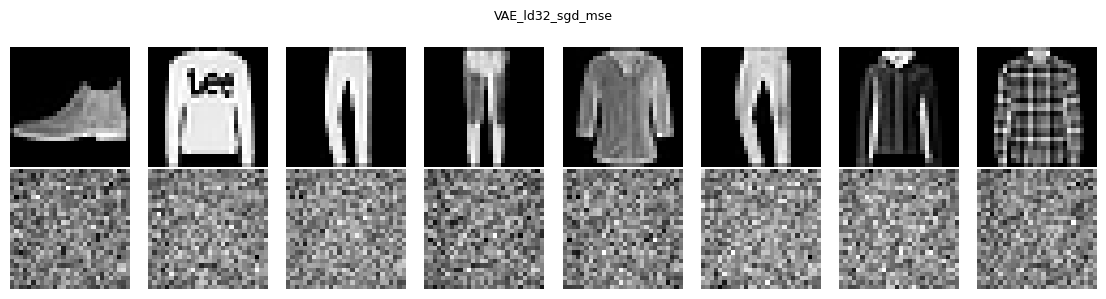

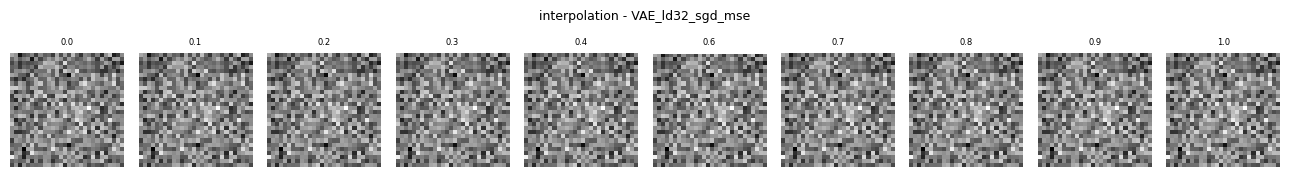

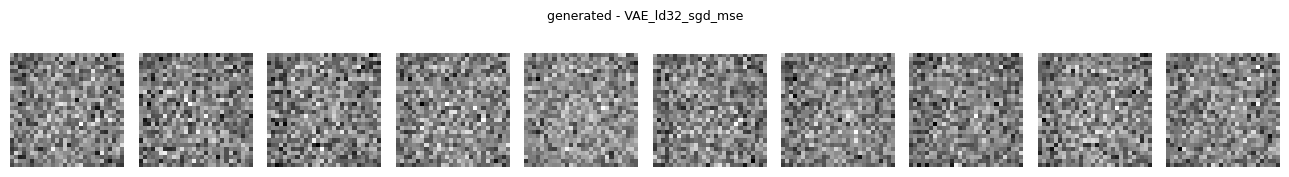

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▄▂▁▁
train_loss,█▆▄▂▁
train_recon,█▆▅▃▁
val_kl,█▄▂▂▁
val_loss,█▆▄▃▁
val_recon,█▆▅▃▁
epoch,5
test_loss,0.16589
train_kl,0.00036



starting: VAE_ld32_rmsprop_bce


  epoch 1/5  train=0.5792  recon=0.4626  kl=0.1166  val=0.4617
  epoch 2/5  train=0.4503  recon=0.4055  kl=0.0448  val=0.4436
  epoch 3/5  train=0.4417  recon=0.3901  kl=0.0515  val=0.4413
  epoch 4/5  train=0.4396  recon=0.3854  kl=0.0542  val=0.4396
  epoch 5/5  train=0.4382  recon=0.3828  kl=0.0554  val=0.4387
  test_loss=0.4389


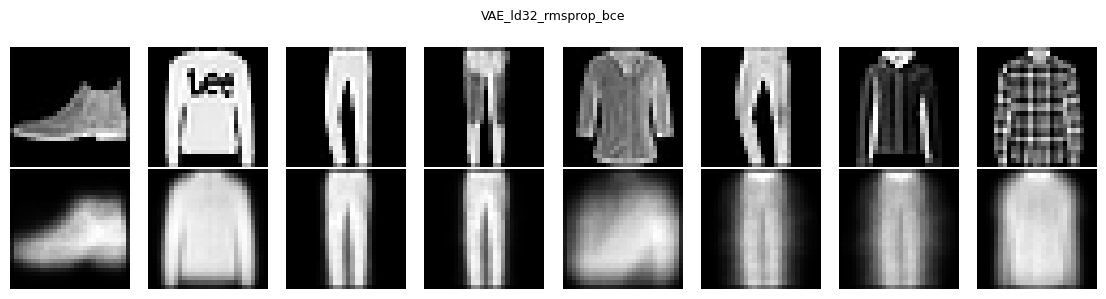

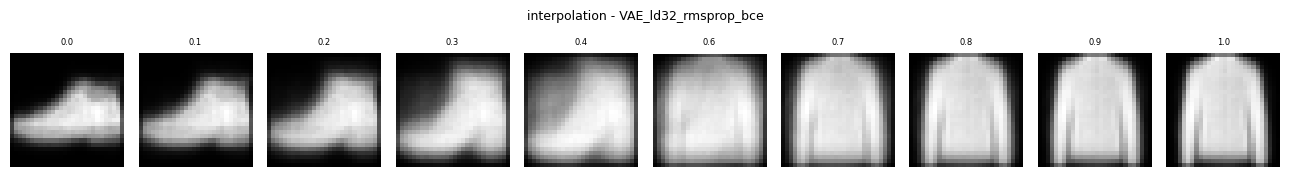

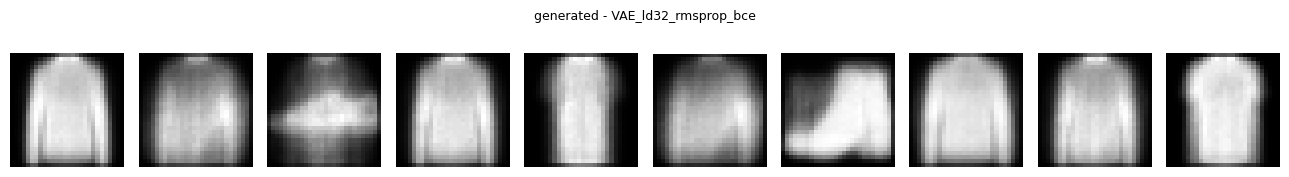

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▂▂▂
train_loss,█▂▁▁▁
train_recon,█▃▂▁▁
val_kl,▁▆███
val_loss,█▂▂▁▁
val_recon,█▃▂▁▁
epoch,5
test_loss,0.43888
train_kl,0.05539



starting: VAE_ld32_rmsprop_mse


  epoch 1/5  train=0.1441  recon=0.0863  kl=0.0578  val=0.0866
  epoch 2/5  train=0.0864  recon=0.0823  kl=0.0042  val=0.0863
  epoch 3/5  train=0.0861  recon=0.0817  kl=0.0044  val=0.0861
  epoch 4/5  train=0.0861  recon=0.0815  kl=0.0046  val=0.0863
  epoch 5/5  train=0.0860  recon=0.0810  kl=0.0050  val=0.0860
  test_loss=0.0851


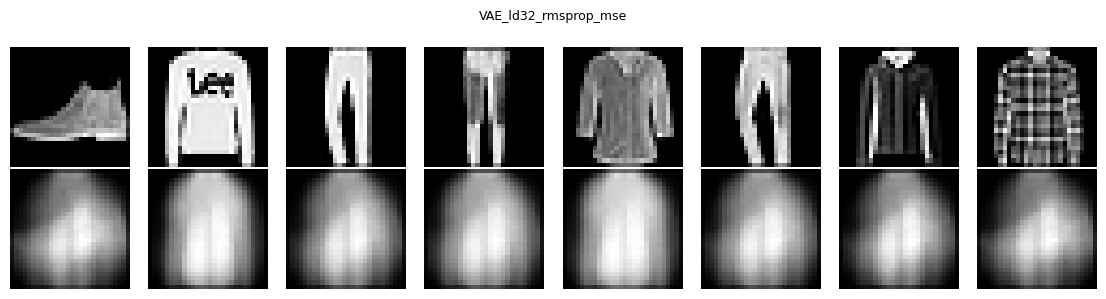

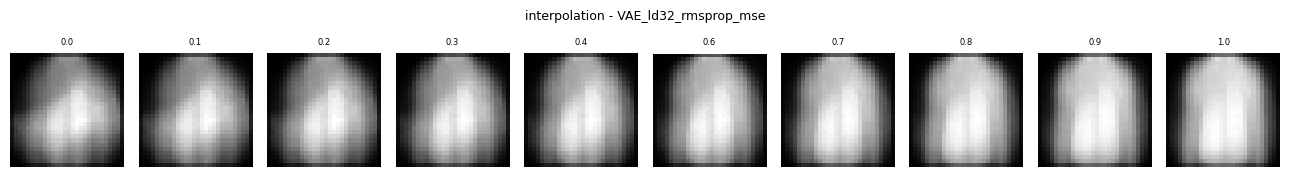

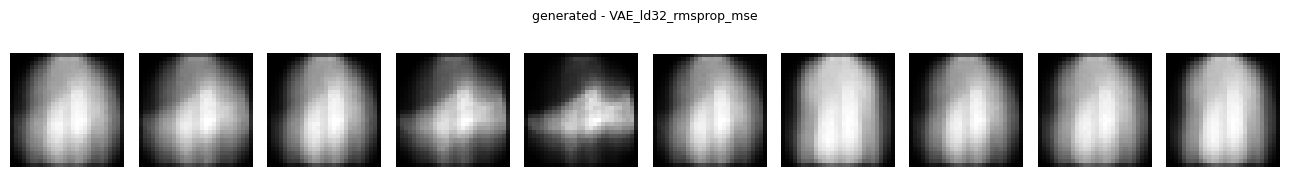

epoch,▁▃▅▆█
test_loss,▁
train_kl,█▁▁▁▁
train_loss,█▁▁▁▁
train_recon,█▃▂▂▁
val_kl,▁▅▅▇█
val_loss,█▅▃▄▁
val_recon,█▄▃▃▁
epoch,5
test_loss,0.0851
train_kl,0.00497


In [13]:
for model_type in ['AE', 'VAE']:
    for ld in LATENT_DIMS:
        for opt in OPTIMIZERS:
            for lf in LOSS_FNS:
                run_experiment(model_type, ld, opt, lf)

### Results Summary

In [14]:
print(f'{"config":<45} {"test_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]):
    print(f'{k:<45} {v:>10.4f}')

best = min(results, key=results.get)
print(f'\nbest: {best}  loss={results[best]:.4f}')

config                                         test_loss
---------------------------------------------------------
AE_ld32_adam_mse                                  0.0131
AE_ld16_adam_mse                                  0.0133
AE_ld8_adam_mse                                   0.0149
AE_ld16_rmsprop_mse                               0.0177
AE_ld32_rmsprop_mse                               0.0179
AE_ld8_rmsprop_mse                                0.0182
AE_ld2_adam_mse                                   0.0283
AE_ld2_rmsprop_mse                                0.0298
VAE_ld32_rmsprop_mse                              0.0851
VAE_ld32_adam_mse                                 0.0853
VAE_ld8_adam_mse                                  0.0867
VAE_ld2_adam_mse                                  0.0868
VAE_ld16_rmsprop_mse                              0.0868
VAE_ld16_adam_mse                                 0.0868
VAE_ld8_rmsprop_mse                               0.0868
VAE_ld2_rmsprop_mse           

### Upload to HuggingFace

In [15]:
import os

create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in trained_models.keys():
    pt_file = f'{name}.pt'
    if os.path.exists(pt_file):
        api.upload_file(
            
            path_or_fileobj=pt_file,
            path_in_repo=f'models/{pt_file}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {pt_file}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: AE_ld16_adam_bce.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

uploaded: VAE_ld32_rmsprop_bce.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: VAE_ld32_rmsprop_mse.pt
https://huggingface.co/HappyKumar25afi21/exp8-ae-vae


In [16]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/happykumar_25afi21-delhi-technological-university/exp8-ae-vae
HF  : https://huggingface.co/HappyKumar25afi21/exp8-ae-vae
